## **Projektgruppe 13 | Modellierung von Energiesystemen**

###  Mitglieder

| Name | Kürzel | Matrikelnummer |
| :---: | :---: | :---: |
| Abdulmalek Alhaj Malek | aalhajma | 11136361 |
| Anne Kölkes | akoelkes | 11505745 |
| Felix Paul Schneegans | fschneeg | 11145145 |
| Joseph Haddad | jhaddad | 11221931 |
| Julian Lemmerz | jlemmerz | 11146171 |



## **Inhalt**

- Projektvorstellung
    - Fragestellung
    - Energiesystem
- Simulation
    - Lastganganalyse
    - Parameter; Komponenten & Constraints implementieren
    - Blackout Analyse
    - Energiesystem Ist-Zustand: PyPSA-Netzwerk aufbauen & lösen
    - Auswertung Dieselaggregat & Notstrom
    - Aufbau Ausbau-Zustand:  PyPSA-Netzwerk aufbauen & lösen
- Auswertung
    - ...
    

>## **Projektvorstellung**

### Bibliotheken

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image , display
import pypsa as ps
import pandas as pd
import numpy as np
import xarray as xr
import linopy
import gurobipy
from linopy.solvers import Gurobi
from datetime import datetime

### Fragestellung

Kann die unterbrechungsfreie **Stromversorgung (USV) eines Krankenhauses** auf Basis von **Photovoltaik und Batteriespeicher** genauso oder **wirtschaftlich besser** umgesetzt werden, unter Zuhilfenahme verschiedener Business Cases, im Vergleich zu herkömmlicher USV? 


### Systemskizze

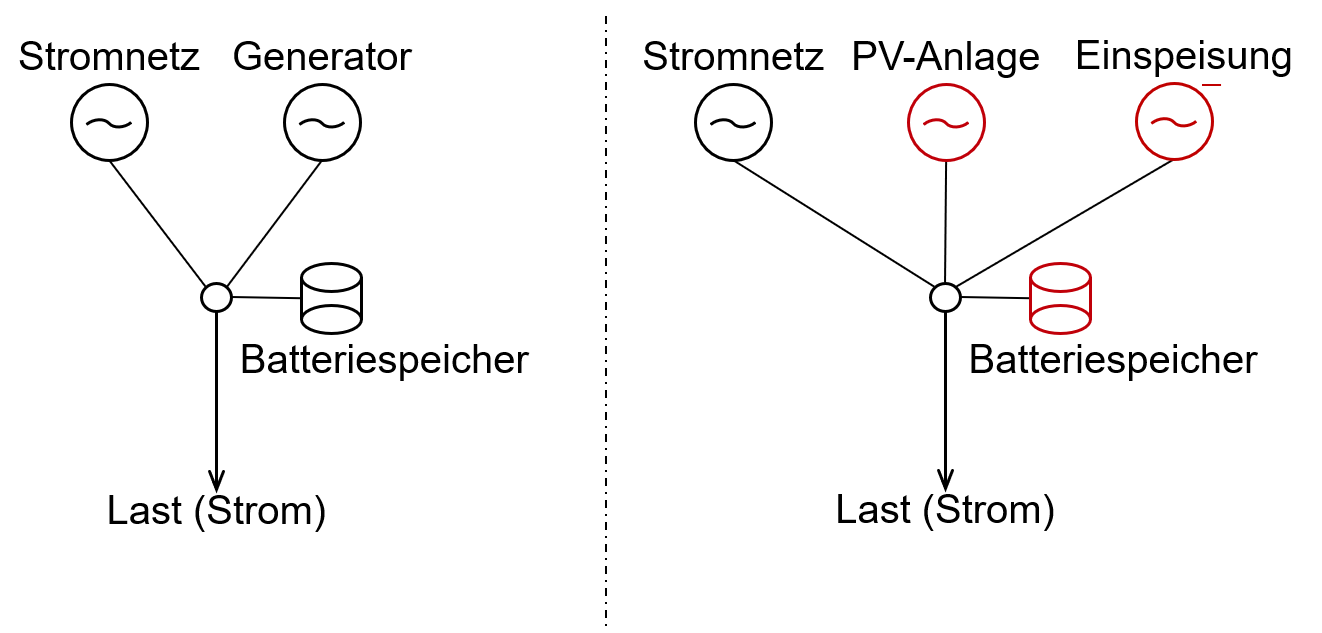

In [7]:
display(Image(filename="Dateien/Abbildungen/Energiesystem - V1.PNG"))
# Batteriespeicher sollen im herkömmlichen Energiesystem raus.
# Da PyPSA Energiesysteme auf einer Zeitskala von 15 Minuten optimiert, lohnt es sich nicht, 
# die kleine USV-Starterbatterie (Überbrückungszeit von wenigen Minuten) explizit zu modellieren. 
# Sie wirkt sich auf dieser Zeitskala kaum aus.

### Das Krankenhaus

Im Rahmen des Forschungsprojektes *"Hybrider Energiespeicher Krankenhaus"* hat das *Fraunhofer-Institut UMSICHT* den thermischen und elektrischen Lastgang eines Krankenhauses aufgezeichnet. Für den Rahmen dieser Untersuchung hat das Institut die Daten großzügiger Weise zur Verfügung gestellt.

Aus dem anhängenden *Abschlussbericht: Hybrider Energiespeicher Krankenhaus* geht allerdings nicht das konkrete Krankenhaus hervor. Eckdaten sind allerdings bekannt:

- 500 Betten
- 14 Fachabteilungen

>## **Simulation**

### Import der Zeitreihen/Last-/Verbrauchsprofile

In [8]:
# Import Stromlastprofil des Krankenhauses
hospital_load_profile = pd.read_csv('Dateien/Stromlastgang_Krankenhaus.csv', sep=';', decimal=",")
hospital_power_demand = hospital_load_profile['kW'] # in kW pro 15 min
hospital_electricity_consumption = hospital_load_profile['kWh'] # in kWh pro 15 min

### **Lastanalyse**

### Stromlastprofil

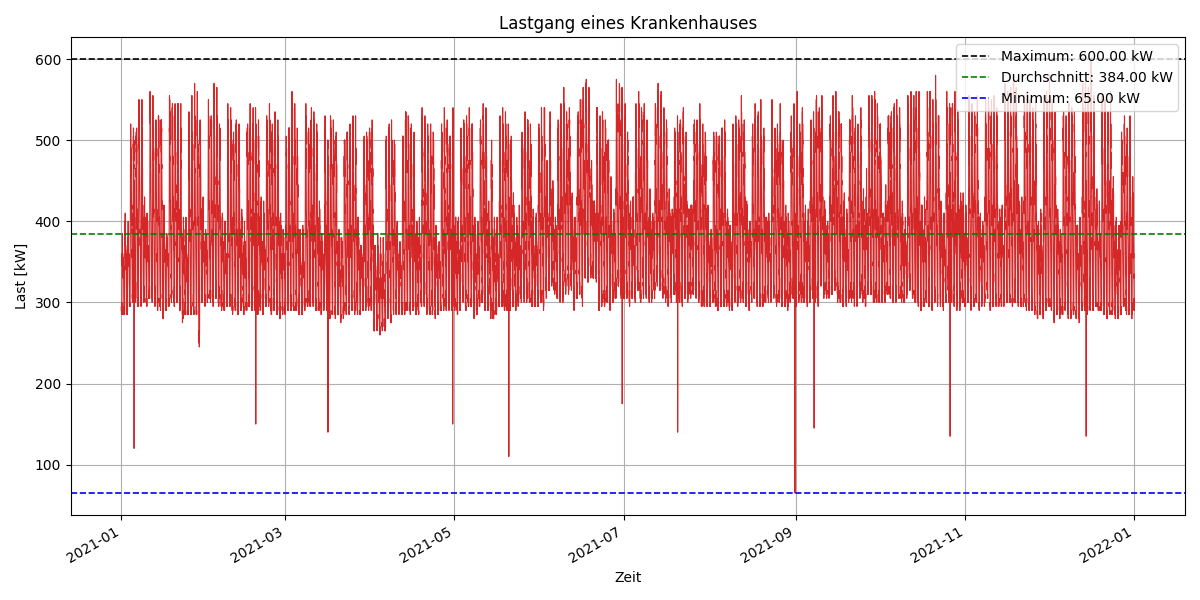

In [9]:
display(Image(filename="Dateien/Abbildungen/Lastgang.png"))

- 15-minütige Auflösung
- Vollständiger Lastgang über ein Jahr (2021) mit 35.040 Werten
- Arbeitswochen (Werktage + Wochenende)

### Heatmap

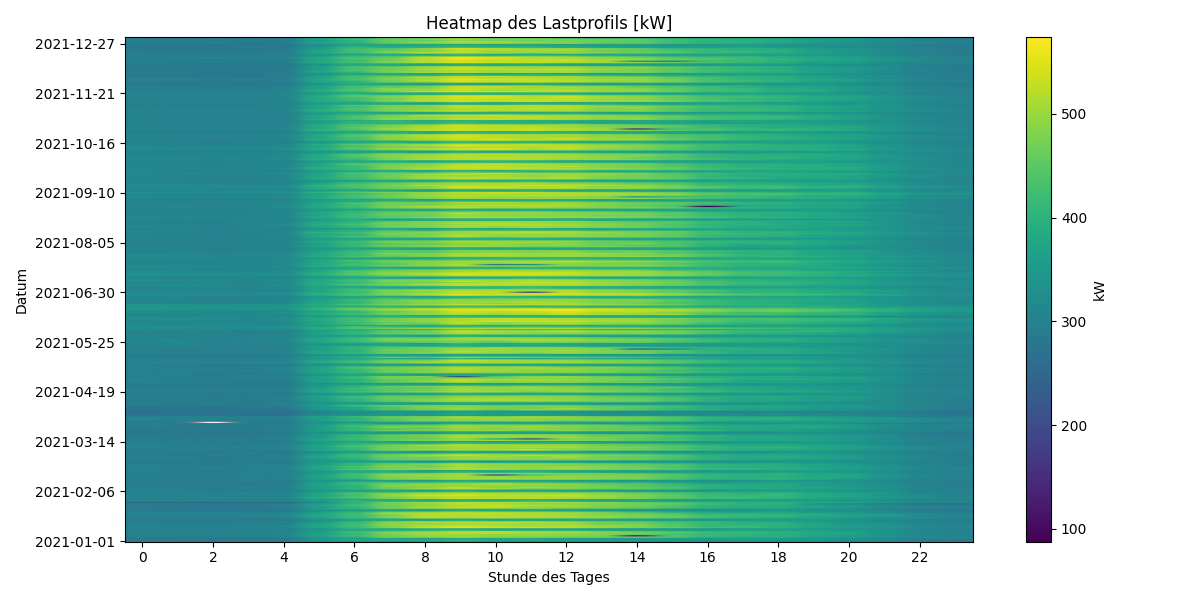

In [10]:
display(Image(filename="Dateien/Abbildungen/Heatmap.png"))

- **Raumwärme** nicht an elektrische Last gekoppelt (Versorgung über Fernwärme)
- mutmaßlich **Kälteanlagen** generieren über die Sommermonate Last
- mutmaßlich **Beleuchtung** zwischen 4:30 Uhr - 21:30 Uhr
- mutmaßlich **Kernarbeitszeit** zwischen 6:30 Uhr - 15:30 Uhr
- Messfehler im Lastprofil:
    - etwa zum 15.04.2021 fehlen rd. 4 Tage
    - innerhalb einiger Tage fehlen wenige Stunden (11 Messfehler)
- Lastprofil liegt ohne Zeitverschiebung vor

>### **Parameter**


### Energiepreise


0        0.20637
1        0.20637
2        0.20637
3        0.20637
4        0.20369
          ...   
35035    0.16060
35036    0.16182
35037    0.16182
35038    0.16182
35039    0.16182
Name: Spotmarktpreis in ct/kWh, Length: 35040, dtype: float64


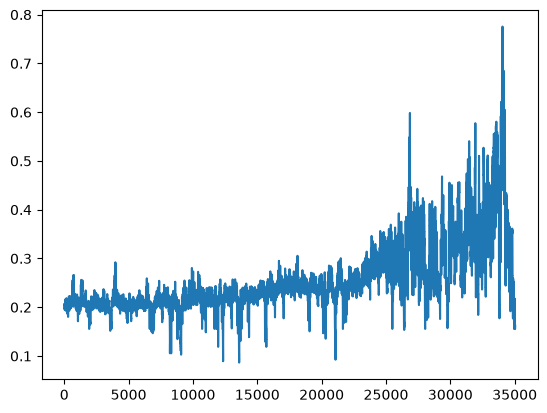

In [11]:
dynamic_tarrifs = True

umlagen_steuern = 0.1555 #€/kWh Quelle:

df_electricity_price = pd.read_csv(r'Dateien\Spotmarktpreise_2021.csv', # Strompreise einlesen. Für statisch & dynamisch genutzt
                                     sep=';',
                                     decimal = ',').iloc[:,5]
df_electricity_price = (df_electricity_price/100) + umlagen_steuern #ct/kWh zu €/kWh
#df_electricity_price = df_electricity_price.drop(df_electricity_price.index[1416:1440]) # Schalttag entfernen

if dynamic_tarrifs == False:
     electricity_price = df_electricity_price.mean()   # Damit  die Datenbasis identisch bleibt, wird hier der Mittelwert des zugrundeliegenden dynamischen Strompreises angegeben
     print(electricity_price)
else:
     electricity_price = df_electricity_price
     electricity_price = electricity_price.repeat(4)    # Stundenwerte auf Viertelstunden erweitern
     electricity_price = electricity_price.reset_index(drop=True)    # alten Index verwerfen
     print(electricity_price)
     plt.plot(electricity_price)
     plt.show

capacity_charge = 21.41  # €/kW/Jahrleistungspreis pro kW Quelle: RheinNetz
infeed_revenue = 0.08 # €/kWh Einspeisevergütung Quelle: bdew
fuel_price = 1.712 # €/l Dieselpreis

#### Energiepreis Regelenergie Primär

In [12]:
fcr_data = pd.read_csv(
    r'Dateien\RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2021-01-01_2021-12-31.csv',
    sep=';',
    decimal=','
)

fcr_data = fcr_data[
    fcr_data["TENDER_NUMBER"] == 1
].copy()

# DATE_FROM in echtes Datum umwandeln
fcr_data["DATE_FROM"] = pd.to_datetime(
    fcr_data["DATE_FROM"],
    format="%d.%m.%Y"
)

missing_day = fcr_data[
    fcr_data["DATE_FROM"] == pd.Timestamp("2021-10-02")
].copy()

missing_day["DATE_FROM"] = pd.Timestamp("2021-10-03")

missing_date = pd.Timestamp("2021-10-03")

if missing_date not in fcr_data["DATE_FROM"].values:

    missing_day = fcr_data[
        fcr_data["DATE_FROM"] == pd.Timestamp("2021-10-02")
    ].copy()

    missing_day["DATE_FROM"] = missing_date

    fcr_data = pd.concat(
        [fcr_data, missing_day],
        ignore_index=True
    )

fcr_data = fcr_data.sort_values(
    ["DATE_FROM", "PRODUCTNAME"]
).reset_index(drop=True)

print(len(fcr_data))

fcr_price_15min = np.repeat(
    fcr_data["CROSSBORDER_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"].to_numpy(),
    16
)

print(len(fcr_price_15min)) 

fcr_data = fcr_data.rename(columns={
    "CROSSBORDER_SETTLEMENTCAPACITY_PRICE_[EUR/MW]": "settlement_cap_price" #€/MW
})

2190
35040


### Stromnetz

In [13]:
grid_import_limit = (12000 / 4) + 600 # kW Spitzenlast (600kW)+ 1000 kW Regelleistung

### Diesel-Generator

In [14]:
diesel_power = 715 # Leistung in kVA
load_factor = 0.8 # Leistungsfaktor
diesel_rated_power = 572 # Nennleistung in kW  studylib.net/doc/28391870/99-2019-health-care-facilities-code-handbook    studylib.net/doc/28037269/nfpa-99-2024-health-care-facilities-code   hospitalinspections.org/report-detail/LN1R21
min_load_factor = 0.3 # Minimale Auslastung
min_diesel_power = 172 # Mindestbetriebspunkt in kW
fuel_consumption_full = 146.7 # Verbrauch Volllast in l/h
fuel_consumption_idle_75 = 110 # Verbrauch Teillast (75%) in l/h
fuel_consumption_idle_50 = 76.4 # Verbrauch Teillast (50%) in l/h
fuel_tank_capacity_epu = 800 # Tankinhalt in l
fuel_storage = 4225 # Treibstoffvorrat in l
fuel_price = fuel_price # Verweis auf gesammelte Energiepreise-Zelle
capex_diesel = 900 # Investitionskosten in €/kW
opex_diesel = 15444 # Betriebskosten in €/a
lifetime_diesel = 20 # Lebensdauer in a
interest_rate = 0.02
annuity_diesel = ((1+interest_rate)**lifetime_diesel)*interest_rate / (((1+interest_rate)**lifetime_diesel)-1)
diesel_cost_per_hour = fuel_consumption_full*fuel_price  # Dieselkosten in €/h bei Vollastbetrieb
diesel_marginal_cost = diesel_cost_per_hour / diesel_rated_power  # Dieselkosten in €/kWh 

### PV-Anlage

In [15]:
infeed_revenue = infeed_revenue # Verweis auf gesammelte Energiepreise-Zelle

area = 15800
utilization_factor = 0.8
specific_power = 7
# Import PV-Erzeugung und weitere Zeitreihen
 
pv_peak_power = (area * utilization_factor) / specific_power      # kWp installierte PV-Leistung
pv_capex = 1250           # €/kWp Investitionskosten
pv_opex = 0.015           # Anteil CAPEX pro Jahr (Betriebskosten, 1,5 %/a)
pv_lifetime = 25          # a Lebensdauer
degradation_rate = 0.005  # -/a jährliche Degradation

interest_rate = 0.02
annuity_pv = ((1+interest_rate)**pv_lifetime)*interest_rate / (((1+interest_rate)**pv_lifetime)-1)
 
# Jährliche Fixkosten pro kWp = lineare Abschreibung + Betriebskosten (Stil wie Diesel)
pv_capital_cost = pv_capex * annuity_pv + pv_opex*pv_capex  # €/kWp/a
 
# --- PV-Erzeugungsprofil (PVGIS Köln, 2021, Referenz 1 kWp) ---
pv_raw = pd.read_csv('Dateien/PV_PyPSA_Erzeugung_h.csv', sep=';', decimal=',')
 
pv_erzeugung = pv_raw['PV Erzeugung [kW]'].to_numpy()   # schon numerisch, da decimal=','
 
# stündlich (8760) -> 15-min (35040): jeden Wert 4x
pv_erzeugung = np.repeat(pv_erzeugung, 4)

### Batteriespeicher

In [16]:
# Ein 4h-System bestimmt das Verhältnis von Kapazität zu Leistung
max_hours = 4.0

# Diskrete Speichergrößen mit linear interpolierten Kosten

def add_discrete_bess_sizes(n, snapshots):
    
    m = n.model
    
# Dynamisch den Namen der Dimension herausfinden (z.B. 'StorageUnit-ext' oder 'StorageUnit')
    p_nom_var = m.variables['StorageUnit-p_nom']
    dim_name = p_nom_var.dims[0]
    p_nom_bess = p_nom_var.sel({dim_name: 'Batteriespeicher'})
    
# Definieren der möglichen Speichergrößen in kWh (500 bis 12000 in 500er Schritten)
    sizes_kwh = np.arange(500, 12500, 500)
    sizes_index = pd.Index(sizes_kwh, name='storage_size')
    
# Interpolation der spezifischen Kosten in €/kWh basierend auf Ihren Stützstellen
    xp = [1000, 3500, 7000, 10000]
    fp = [360, 310, 285, 273]
    
# np.interp interpoliert linear zwischen den Punkten
    spec_costs = np.interp(sizes_kwh, xp, fp)
    
# Binärvariablen für jede der möglichen Größen erstellen
    bin_vars = m.add_variables(binary=True, coords=[sizes_index], name='storage_selector')
    
# Constraint 1: Es darf maximal EINE Speichergröße ausgewählt werden
    m.add_constraints(bin_vars.sum() == 1, name='select_at_most_one_size')
    
# Constraint 2: Die Kapazität im PyPSA-Netzwerk (p_nom in kW) an die Auswahl knüpfen
    power_kw = sizes_kwh / (max_hours)
    power_da = xr.DataArray(power_kw, coords=[sizes_index])
    m.add_constraints(p_nom_bess == (bin_vars * power_da).sum(), name='link_size_to_pnom')

# Constraint 3: Energie vorhalten für möglichen Blackout
    soc_var = m.variables["StorageUnit-state_of_charge"]

    soc_storage_dim = [
        dim for dim in soc_var.dims
        if dim != "snapshot"
    ][0]

    # Komplette SOC-Zeitreihe des Batteriespeichers auswählen
    soc_bess = soc_var.sel({
        soc_storage_dim: "Batteriespeicher"
    })

    # Dauer der Wiederaufladephase nach dem Blackout
    recharge_duration_h = 24

    # Anzahl der Zeitschritte der Wiederaufladephase
    recharge_steps = recharge_duration_h * steps_per_hour

    # Standard:
    # Außerhalb von Blackout und Wiederaufladephase
    # muss die vollständige Blackoutreserve vorhanden sein
    min_soc = np.full(
        len(n.snapshots),
        blackout_reserve_kwh,
        dtype=float
    )

    # Ende des Blackouts
    blackout_end = blackout_start + blackout_steps

    # Während des Blackouts darf die gesamte Reserve verwendet werden
    min_soc[
        blackout_start:blackout_end
    ] = 0.0

    # Ende der Wiederaufladephase
    recharge_end = min(
        blackout_end + recharge_steps,
        len(n.snapshots)
    )

    # Tatsächlich vorhandene Zeitschritte für die Wiederaufladung
    n_recharge_steps = recharge_end - blackout_end

    # Nach dem Blackout steigt die vorgeschriebene Mindestenergie
    # linear wieder bis auf die vollständige Blackoutreserve an
    if n_recharge_steps > 0:
        min_soc[
            blackout_end:recharge_end
        ] = np.linspace(
            0,
            blackout_reserve_kwh,
            n_recharge_steps + 1
        )[1:]

    # NumPy-Zeitreihe in xarray umwandeln
    min_soc_da = xr.DataArray(
        min_soc,
        coords={"snapshot": n.snapshots},
        dims=["snapshot"]
    )

    # Harte Randbedingung:
    # tatsächlicher Energieinhalt >= geforderte Mindestreserve
    m.add_constraints(
        soc_bess >= min_soc_da,
        name="BESS_blackout_energy_reserve"
    )


    
# Zielfunktion: Gesamtkosten (Investition * Annuität) der gewählten Größe hinzufügen
    interest_rate = 0.02
    lifespan = 15
    annuity_factor = ((1+interest_rate)**lifespan)*interest_rate / (((1+interest_rate)**lifespan)-1)
    total_capex_annuity = sizes_kwh * spec_costs * annuity_factor
    costs_da = xr.DataArray(total_capex_annuity, coords=[sizes_index])
    m.objective += (bin_vars * costs_da).sum()



### Blackout-Parameter

In [17]:
blackout = True 
critical_load_share = 0.8 # dke.de/de/normen-standards/dokument?id=7020397&type=dke%7Cdokument&     nature.com/articles/s41598-026-56638-8
# Für die Simulation wird angenommen, dass im Falle eines Netzausfalls 80 % des elektrischen Lastprofils als kritische Last aufrechterhalten werden müssen. Die DIN VDE 0100-710 fordert eine Sicherheitsstromversorgung für sicherheitsrelevante Verbraucher in medizinisch genutzten Bereichen, gibt jedoch keinen pauschalen prozentualen Anteil an der Gesamtlast vor. Der kritische Lastanteil wird daher als Modellannahme festgelegt. Vergleichbare wissenschaftliche Untersuchungen von Krankenhaus-Microgrids verwenden ebenfalls prozentuale kritische Lastanteile, beispielsweise 70 %
critical_load = hospital_power_demand * critical_load_share  # kritische Last
blackout_duration_h = 24  # 24-stündiger Blackout
steps_per_hour = 4  # 15-min-Auflösung
blackout_steps = blackout_duration_h * steps_per_hour  # Blackout-Zeitschritte

### **Energiesysteme: Ist-Zustand & Upgrade**

### Tag mit höchstem Energieverbrauch

In [18]:
# Anzahl der Zeitschritte pro Tag
steps_per_day = 96

# Tagesnummer erzeugen
hospital_load_profile["Tag"] = hospital_load_profile.index // steps_per_day

# Energie pro Tag aufsummieren
daily_energy = hospital_load_profile.groupby("Tag")["kWh"].sum()

# Tag mit maximalem Energieverbrauch
max_day = daily_energy.idxmax()
max_energy = daily_energy.max()

print(f"Tag mit höchstem Energieverbrauch: {max_day}")
hospital_load_profile["Ab-Datum"] = pd.to_datetime(hospital_load_profile["Ab-Datum"],format="%d.%m.%Y")
datum = (hospital_load_profile[hospital_load_profile["Tag"] == max_day].iloc[0]["Ab-Datum"])
print(f"Datum: {datum.strftime('%d.%m.%Y')}")
print(f"Energieverbrauch: {max_energy:,.0f} kWh".replace(",", "."))


Tag mit höchstem Energieverbrauch: 167
Datum: 17.06.2021
Energieverbrauch: 10.806 kWh


### Maximale rollierende 24-stündige Energie

In [ ]:
# Anzahl der Zeitschritte für 24 Stunden
window = 96

# Rollierende 24-h-Energiesumme
rolling_energy = (hospital_load_profile["kWh"].rolling(window=window).sum())

# Maximale 24-h-Energie
max_energy = rolling_energy.max()

# Endindex des Fensters
end_idx_24h_energy = rolling_energy.idxmax()



# Startindex des Fensters
start_idx_24h_energy = end_idx_24h_energy - window + 1

blackout_reserve_kwh = max_energy * critical_load_share

print(f"Start-Zeitschritt: {start_idx_24h_energy}")
print(f"End-Zeitschritt: {end_idx_24h_energy}")
start_date = hospital_load_profile.loc[start_idx_24h_energy, "Ab-Datum"]
end_date = hospital_load_profile.loc[end_idx_24h_energy, "Ab-Datum"]
start_time = hospital_load_profile.loc[start_idx_24h_energy, "Ab-Zeit"]
end_time = hospital_load_profile.loc[end_idx_24h_energy, "Ab-Zeit"]
print("Beginn:",start_date.strftime("%d.%m.%Y"), start_time)
print("Ende:",end_date.strftime("%d.%m.%Y"), end_time)
print(f"Maximale rollierende 24-h-Energie: {max_energy:,.0f} kWh".replace(",", "."))

energy_day167 = daily_energy.loc[167]
if max_energy > energy_day167:
    print("Es existieren 24 aufeinanderfolgende Stunden mit höherem Energieverbrauch als Tag 167.")
else:
    print("Tag 167 besitzt bereits die höchste 24-h-Energie.")

if blackout_reserve_kwh is not None:
    print(f'Benötigte Blackout Reserve auf {blackout_reserve_kwh:,.0f} kWh gesetzt'.replace(',','.') )

Start-Zeitschritt: 16063
End-Zeitschritt: 16158
Beginn: 17.06.2021 08:45:00
Ende: 18.06.2021 08:30:00
Maximale rollierende 24-h-Energie: 10.858 kWh
Es existieren 24 aufeinanderfolgende Stunden mit höherem Energieverbrauch als Tag 167.
Benötigte Blackout Reserve auf 8.686 kWh gesetzt


### Tag mit höchster Spitzenlast

In [20]:
# Maximale Leistung je Tag
daily_peak = hospital_load_profile.groupby("Tag")["kW"].max()

# Tag mit der höchsten Spitzenlast
peak_day = daily_peak.idxmax()
peak_power = daily_peak.max()

print(f"Tag mit höchster Spitzenlast: {peak_day}")
datum = (hospital_load_profile[hospital_load_profile["Tag"] == peak_day].iloc[0]["Ab-Datum"])

# Erster Zeitschritt des Peak-Tages
start_idx_max_power = hospital_load_profile[hospital_load_profile["Tag"] == peak_day].index.min()

# Letzter Zeitschritt (24 Stunden)
end_idx_max_power = start_idx_max_power + 96

print("Startzeitschritt:", start_idx_max_power)
print("Endzeitschritt:", end_idx_max_power - 1)
print(f"Datum: {datum.strftime('%d.%m.%Y')}")
print(f"Spitzenlast: {peak_power:.0f} kW")

Tag mit höchster Spitzenlast: 349
Startzeitschritt: 33504
Endzeitschritt: 33599
Datum: 16.12.2021
Spitzenlast: 600 kW


### Blackout-Tage

In [21]:
blackout_start_max_energy = start_idx_24h_energy  # 24 Stunden mit höchstem Energieverbrauch
blackout_start_max_power = start_idx_max_power  # Tag mit höchster Spitzenlast
blackout_start = blackout_start_max_energy  # !!! Variabel: alternativ blackout_start_max_power

### **Ist-Zustand**

In [22]:
# PyPSA-Netzwerk für das herkömmliche Energiesystem
n_is = ps.Network()
n_is.set_snapshots(range(35040)) # 35.040 Zeitschritte für 15-minütige Daten über ein Jahr

c:\Users\jlemm\OneDrive - TH Köln\VSC\.venv_laptop\Lib\site-packages\pypsa\network\io.py:2082: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)


### Blackout-Implementierung

In [23]:
# Netzverfügbarkeit
grid_availability_is = np.ones(len(n_is.snapshots))

# Lastprofil für den Ist-Zustand
load_is = hospital_power_demand.copy()

if blackout:

    # Stromnetz fällt während des Blackouts aus
    grid_availability_is[blackout_start : blackout_start + blackout_steps] = 0

    # Während des Blackouts bleibt nur die kritische Last bestehen
    load_is.iloc[blackout_start : blackout_start + blackout_steps] = critical_load.iloc[blackout_start : blackout_start + blackout_steps]

### Monatlicher Funktionstest mit mindestens 80 % Last

In [24]:
# test_load_factor = 0,8 bis 1  buffl.co/en/community/c/656342c3a807ecc023c9cbac

steps_per_hour = 4
steps_per_day = 96

test_days = [4, 45, 74, 103, 136, 164, 194, 227, 256, 286, 318, 347]
test_mask = np.zeros(len(n_is.snapshots), dtype=bool)
for day in test_days:
    start = day * steps_per_day + 12*steps_per_hour  # Test beginnt um 12:00 Uhr
    test_mask[start:start+steps_per_hour] = True   # 1 Stunde = 4 Viertelstunden

# Während der Teststunden kein Netzstrom
grid_availability_is[test_mask] = 0

# Geänderte Netzverfügbarkeit an PyPSA übergeben
n_is.generators_t.p_max_pu["grid_power"] = grid_availability_is

### Dieselgenerator-Verfügbarkeit

In [25]:
# Maske für Blackout
blackout_mask = np.zeros(len(n_is.snapshots), dtype=bool)

blackout_mask[blackout_start:blackout_start + blackout_steps] = True

# Dieselgeneratorverfügbarkeit
diesel_availability = np.zeros(len(n_is.snapshots))

# Dieselgenerator während Blackout verfügbar
diesel_availability[blackout_mask] = 1

# Dieselgenerator während Funktionstests verfügbar
diesel_availability[test_mask] = 1

n_is.generators_t.p_max_pu["diesel_generator"] = diesel_availability

### Aufbau des PyPSA-Netzwerks

In [26]:
#Bus
n_is.add('Bus',name = 'electricity')

#Carrier
n_is.add("Carrier",name="diesel")

#Load
n_is.add('Load',name = 'electrical_load',bus = 'electricity',p_set = load_is)

#Generator
n_is.add('Generator',name = 'grid_power',bus = 'electricity',carrier = 'diesel',p_nom = grid_import_limit,
         p_max_pu = grid_availability_is,marginal_cost = electricity_price,capital_cost = capacity_charge)

n_is.add('Generator', name="diesel_generator", bus="electricity", p_nom=diesel_rated_power,p_min_pu=min_load_factor, 
         marginal_cost=diesel_marginal_cost, committable=True, start_up_cost=80)

### **Auswertung**

### Netzwerkoptimierung

In [27]:
n_is.optimize(solver_name="highs")

C:\Users\jlemm\AppData\Local\Temp\ipykernel_5200\3815676144.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_is.optimize(solver_name="highs")
Index(['electricity'], dtype='object', name='name')
Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       35030, 35031, 35032, 35033, 35034, 35035, 35036, 35037, 35038, 35039],
      dtype='int64', name='snapshot', length=34896)
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 220.11it/s]
INFO:linopy.io: Writing time: 0.42s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 175200 primals, 385440 duals
Objective: 3.45e+

('ok', 'optimal')

### Monatlicher Funktionstest mit mindestens 80 % Last

In [28]:
diesel_power_test = n_is.generators_t.p["diesel_generator"][test_mask]
diesel_load_share_test_percent = (diesel_power_test / diesel_rated_power * 100)
within_range = ((diesel_load_share_test_percent >= 80) &(diesel_load_share_test_percent <= 100))
test_check = pd.DataFrame({
    "Krankenhauslast [kW]":load_is.iloc[test_mask].to_numpy(),
    "Netz [kW]":n_is.generators_t.p["grid_power"].iloc[test_mask].to_numpy().round(0).astype(int),
    "Diesel [kW]":n_is.generators_t.p["diesel_generator"].iloc[test_mask].to_numpy().round(0).astype(int),
    "Diesel-Auslastung [%]":(n_is.generators_t.p["diesel_generator"].iloc[test_mask].to_numpy()/ diesel_rated_power * 100).round(0).astype(int)},
     index=n_is.snapshots[test_mask])

test_check.index.name = "Zeitschritt"
test_check["Netz [kW]"] = (test_check["Netz [kW]"].where(test_check["Netz [kW]"].abs() > 1e-6, 0))
display(test_check.round(1))
print("Alle Werte der Diesel-Auslastung zwischen 80 % und 100 %:", within_range.all())

,Krankenhauslast [kW],Netz [kW],Diesel [kW],Diesel-Auslastung [%]
Zeitschritt,,,,
432,485,0,485,85
433,485,0,485,85
434,475,0,475,83
435,485,0,485,85
4368,515,0,515,90
4369,520,0,520,91
4370,480,0,480,84
4371,475,0,475,83
7152,480,0,480,84


Alle Werte der Diesel-Auslastung zwischen 80 % und 100 %: True


### Kraftstoffverbrauch nach der Optimierung

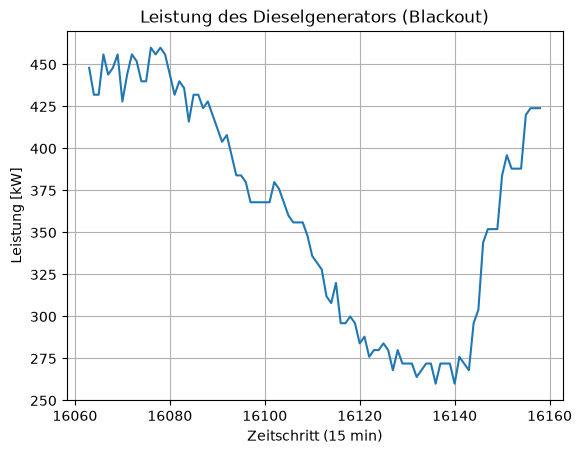

,Leistung des Dieselgenerators (Blackout) [kW]
snapshot,
16063,448
16064,432
16065,432
16066,456
16067,444
...,...
16154,388
16155,420
16156,424


In [29]:
diesel_generator_power_output = n_is.generators_t.p["diesel_generator"]
plt.plot(diesel_generator_power_output[blackout_start : blackout_start + blackout_steps])
plt.title("Leistung des Dieselgenerators (Blackout)")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")
plt.grid(True)
plt.show()
diesel_blackout_df = diesel_generator_power_output[blackout_start : blackout_start + blackout_steps].to_frame(name="Leistung des Dieselgenerators (Blackout) [kW]")
diesel_blackout_df.astype(int)

### Lineare Interpolation der Verbrauchskennlinie

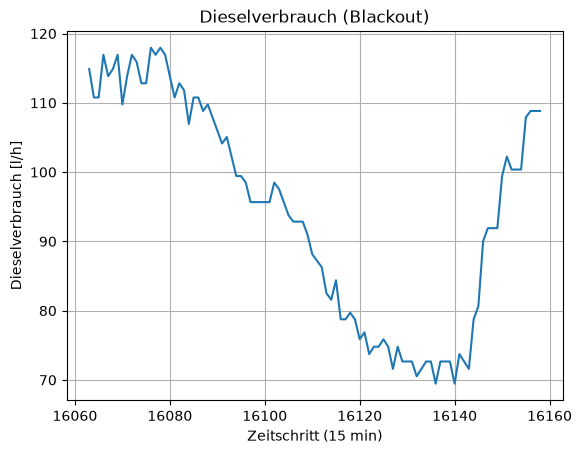

,Dieselverbrauch [l/h]
Zeitschritt,
16063,115
16064,111
16065,111
16066,117
16067,114
...,...
16154,100
16155,108
16156,109


In [30]:
def diesel_consumption(power):  # Dieselverbrauch in l/h

    load = power / diesel_rated_power  # Anteil der Nennleistung

    if load <= 0:  # Generator aus → kein Kraftstoffverbrauch
        return 0

    elif load <= 0.5:  # Bereich zwischen 0% und 50% Teillast
        return fuel_consumption_idle_50 * load / 0.5

    elif load <= 0.75:  # Bereich zwischen 50% und 75% Teillast
        return fuel_consumption_idle_50 + \
               (fuel_consumption_idle_75-fuel_consumption_idle_50) * \
               (load-0.5)/0.25

    else:  # Bereich über 75%
        return fuel_consumption_idle_75 + \
               (fuel_consumption_full-fuel_consumption_idle_75) * \
               (load-0.75)/0.25

fuel = diesel_generator_power_output.apply(diesel_consumption)  # Zeitreihe mit Dieselverbrauch l/h
plt.plot(fuel[blackout_start : blackout_start + blackout_steps])
plt.title("Dieselverbrauch (Blackout)")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Dieselverbrauch [l/h]")
plt.grid(True)
plt.show()
fuel_df = fuel.to_frame(name="Dieselverbrauch [l/h]")
fuel_df[blackout_start : blackout_start + blackout_steps]
fuel_df.index.name = "Zeitschritt"
fuel_df[blackout_start : blackout_start + blackout_steps].round(0).astype(int)

#### Gesamtdieselverbrauch im Simulationsjahr 

In [31]:
# Tatsächliche Dieselgeneratorleistung aus PyPSA
diesel_power_output = n_is.generators_t.p["diesel_generator"]

# Kraftstoffverbrauch für jeden Zeitschritt
fuel = diesel_power_output.apply(diesel_consumption)

# Dieselverbrauch (Blackout)
fuel_blackout = (fuel.iloc[blackout_start:blackout_start + blackout_steps] * 0.25).sum()
formatted_fuel_blackout = f"{fuel_blackout:,.0f}".replace(",", ".")
print("Dieselverbrauch (Blackout):",formatted_fuel_blackout,"l")

# Dieselverbrauch (Funktionstests)
fuel_test_total = (fuel.iloc[test_mask] * 0.25).sum()
formatted_fuel_test = f"{fuel_test_total:,.0f}".replace(",", ".")
print("Dieselverbrauch (Funktionstests):",formatted_fuel_test,"l")

# Gesamtdieselverbrauch
fuel_total = (fuel * 0.25).sum()
formatted_fuel_total = f"{fuel_total:,.0f}".replace(",", ".")
print("Gesamtdieselverbrauch:",formatted_fuel_total,"l")

Dieselverbrauch (Blackout): 2.261 l
Dieselverbrauch (Funktionstests): 1.518 l
Gesamtdieselverbrauch: 3.779 l


#### Gesamtdieselkosten im Simulationsjahr 

In [32]:
# Dieselkosten (Blackout)
fuel_cost_blackout = fuel_blackout * fuel_price
formatted_fuel_cost_blackout = (f"{fuel_cost_blackout:,.0f}".replace(",", "."))
print("Dieselkosten (Blackout):",formatted_fuel_cost_blackout,"€")

# Dieselkosten (Funktionstests)
fuel_cost_test = fuel_test_total * fuel_price
formatted_fuel_cost_test = (f"{fuel_cost_test:,.0f}".replace(",", "."))
print("Dieselkosten (Funktionstests):",formatted_fuel_cost_test,"€")

# Gesamtdieselkosten
fuel_cost_total = fuel_total * fuel_price
formatted_fuel_cost_total = (f"{fuel_cost_total:,.0f}".replace(",", "."))
print("Gesamtdieselkosten:",formatted_fuel_cost_total,"€")


Dieselkosten (Blackout): 3.871 €
Dieselkosten (Funktionstests): 2.598 €
Gesamtdieselkosten: 6.470 €


#### Betriebsstunden im Simulationsjahr 

In [33]:
running = diesel_generator_power_output > 0
operating_hours = running.sum() * 0.25
print("Betriebsstunden:", round(operating_hours), "h")

Betriebsstunden: 36 h


#### Anzahl an Starts im Simulationsjahr 

In [34]:
starts = ((running.astype(int).diff()) == 1).sum()
print("Anzahl an Starts:", starts)

Anzahl an Starts: 13


### Ergebnisse des PyPSA-Netzwerks

In [35]:
# Strometz-OPEX bei dynamischen Tarifen

grid_power = n_is.generators_t.p["grid_power"]
grid_energy_t = grid_power * 0.25  # kWh je 15 min

if "grid_power" in n_is.generators_t.marginal_cost.columns:
    # dynamischer Strompreis
    grid_price_t = n_is.generators_t.marginal_cost["grid_power"]
    grid_opex = (grid_energy_t * grid_price_t).sum()

else:
    # konstanter Strompreis
    grid_price = n_is.generators.at["grid_power", "marginal_cost"]
    grid_opex = grid_energy_t.sum() * grid_price


# Dieselgenerator-CAPEX
n_is.generators.at["diesel_generator","capital_cost"] = annuity_diesel*capex_diesel

# Dieselgenerator-OPEX
diesel_opex = fuel_cost_total

# OPEX für beide Generatoren
opex = pd.Series({"grid_power": grid_opex,"diesel_generator": diesel_opex})

generator_energy_total = n_is.generators_t.p.sum() * 0.25  # kWh je 15 min

generator_stats = pd.DataFrame({
    "Installierte Leistung [kW]": n_is.generators.p_nom.astype(int),

    "Maximale Leistung [kW]": n_is.generators_t.p.max().round(0).astype(int),

    "Erzeugte Energie [kWh]": generator_energy_total.round(0).astype(int).map(lambda x: f"{x:,}".replace(",", ".")),

    "OPEX [€]": opex.astype(int).map(lambda x: f"{x:,}".replace(",", ".")),

    "CAPEX [€/a]": (n_is.generators.capital_cost * n_is.generators.p_nom).round(0).astype(int).map(lambda x: f"{x:,}".replace(",", ".")),})

generator_stats

,Installierte Leistung [kW],Maximale Leistung [kW],Erzeugte Energie [kWh],OPEX [€],CAPEX [€/a]
grid_power,3600,600,3.347.028,855.141,77.076
diesel_generator,572,535,14.605,6.469,31.483


### **Upgrade**

In [36]:
#PyPSA-Netzwerk für das neue Energiesystem
n_up = ps.Network()
n_up.set_snapshots(range(35040)) # 35040 Zeitschritte für 15-minütige Daten über ein Jahr
n_up.snapshot_weightings.loc[:, :] = 0.25  # Jeder Snapshot repräsentiert 0,25 Stunden und nicht 1 Stunde.

### Blackout-Implementierung

In [37]:
# Blackout-Maske
blackout_mask = np.zeros(len(n_up.snapshots), dtype=bool)

if blackout:

    blackout_mask[blackout_start:blackout_start + blackout_steps] = True

# Netzverfügbarkeit
grid_availability_up = np.ones(len(n_up.snapshots))

# Lastprofil für das Upgrade-System
load_up = hospital_power_demand.copy()

if blackout:

    # Stromnetz fällt während des Blackouts aus
    grid_availability_up[blackout_start : blackout_start + blackout_steps] = 0


    # Während des Blackouts bleibt nur die kritische Last bestehen
    load_up.iloc[blackout_start : blackout_start + blackout_steps] = critical_load.iloc[blackout_start : blackout_start + blackout_steps]

n_up.generators_t.p_max_pu["grid_power"] = grid_availability_up

### Aufbau des PyPSA-Netzwerks

In [38]:
#Bus
n_up.add('Bus',name = 'electricity')

#Load
n_up.add('Load',name = 'electrical_load',bus = 'electricity',p_set = load_up)

#Generator
n_up.add('Generator',name = 'grid_power',bus = 'electricity',p_nom = grid_import_limit,p_max_pu = grid_availability_up,
         marginal_cost = electricity_price,capital_cost = capacity_charge,overwrite=True)

n_up.add('Generator',name = 'infeed',bus = 'electricity',p_nom = pv_peak_power,min_pu=0,p_max_pu=grid_availability_up,
         sign=-1,marginal_cost=-infeed_revenue)
 
n_up.add('Generator',name = 'pv',bus = 'electricity',p_nom = pv_peak_power,p_max_pu = pv_erzeugung,        
         capital_cost = pv_capital_cost,marginal_cost = 0)

n_up.add('StorageUnit', name ='Batteriespeicher',bus='electricity',p_nom = 0,p_nom_extendable=True,
         capital_cost=0,max_hours=max_hours,efficiency_store=0.922,efficiency_dispatch=0.922,
         cyclic_state_of_charge=True)

### Business Case: Bereitstellung von Primärregelleistung (FCR)

In [39]:

max_hours = 4
dt_h = 0.25

fcr_freq = pd.read_csv(r"Dateien\FCR_Netzfrequenz_2021_15min_Aktivierungsfaktor.csv", sep=";", decimal=",")
fcr_freq["timestamp"] = pd.to_datetime(fcr_freq["timestamp"], format="%d.%m.%Y %H:%M")
print(len(fcr_freq))
assert len(fcr_freq) == len(n_up.snapshots)  # Ein FCR-Wert gehört genau zu jedem PyPSA-Snapshot

af_positive = (fcr_freq["activation_factor_positive"].copy())
af_negative = (fcr_freq["activation_factor_negative"].copy())
af_positive.index = n_up.snapshots
af_negative.index = n_up.snapshots

n_up.storage_units.at["Batteriespeicher","p_nom"] = 0.0
n_up.storage_units.at["Batteriespeicher","p_nom_extendable"] = True

blackout_mask = np.zeros(len(n_up.snapshots),dtype=bool)
blackout_mask[blackout_start:blackout_start + blackout_steps] = True

af_positive.loc[n_up.snapshots[blackout_mask]] = 0  # FCR während des Blackouts deaktiviert
af_negative.loc[n_up.snapshots[blackout_mask]] = 0  # FCR während des Blackouts deaktiviert

# BESS ganzjährig technisch verfügbar
n_up.storage_units_t.p_max_pu["Batteriespeicher"] = 1.0
n_up.storage_units_t.p_min_pu["Batteriespeicher"] = -1.0

fcr_price = pd.read_csv(r"Dateien\RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2021-01-01_2021-12-31.csv",sep=";",decimal=",")

# Nur erste Ausschreibung
fcr_price = fcr_price[fcr_price["TENDER_NUMBER"] == 1].copy()
fcr_price["DATE_FROM"] = pd.to_datetime(fcr_price["DATE_FROM"],format="%d.%m.%Y")
price_col = "DE_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"
fcr_price[price_col] = pd.to_numeric(fcr_price[price_col].astype(str).str.replace(",", ".", regex=False),errors="coerce")
#print(fcr_price[price_col].describe())

missing_date = pd.Timestamp("2021-10-03")
if missing_date not in fcr_price["DATE_FROM"].values:

    copy_day = fcr_price[fcr_price["DATE_FROM"]== pd.Timestamp("2021-10-02")].copy()
    copy_day["DATE_FROM"] = missing_date
    fcr_price = pd.concat([fcr_price, copy_day],ignore_index=True)

print("Anzahl Zeilen:", len(fcr_price))
print("Anzahl Tage:", fcr_price["DATE_FROM"].nunique())

product_order = {"NEGPOS_00_04": 0, "NEGPOS_04_08": 1,"NEGPOS_08_12": 2,"NEGPOS_12_16": 3,"NEGPOS_16_20": 4,"NEGPOS_20_24": 5}
fcr_price["product_order"] = (fcr_price["PRODUCTNAME"].map(product_order))
fcr_price = (fcr_price.sort_values(["DATE_FROM", "product_order"]).reset_index(drop=True))

fcr_price_sum = (fcr_price[price_col].sum())
fcr_revenue_per_kw = (fcr_price_sum / 1000)
print("FCR-Erlös:",f"{fcr_revenue_per_kw:,.0f}".replace(",", "."),"€/kW/a")
print("Summe der FCR-Preise:",f"{fcr_price[price_col].sum():,.0f}".replace(",", "."),"€/MW")
print("Mittlerer Preis pro 4-h-Produkt:",f"{fcr_price[price_col].mean():,.0f}".replace(",", "."),"€/MW")

def add_fcr_optimization(n, snapshots):

    m = n.model

# BESS-Leistung als Optimierungsvariable

    p_nom_var = m.variables["StorageUnit-p_nom"]
    p_nom_dim = p_nom_var.dims[0]
    p_nom_bess = p_nom_var.sel({p_nom_dim: "Batteriespeicher"})

# PyPSA-BESS-Variablen
 
    p_dispatch_var = m.variables["StorageUnit-p_dispatch"]
    p_store_var = m.variables["StorageUnit-p_store"]
    soc_var = m.variables["StorageUnit-state_of_charge"]

# StorageUnit-Dimension automatisch erkennen
    storage_dim = [dim for dim in p_dispatch_var.dims if dim != "snapshot"][0]
    soc_storage_dim = [dim for dim in soc_var.dims if dim != "snapshot"][0]

# Nur Batteriespeicher auswählen

    p_dispatch_bess = p_dispatch_var.sel({storage_dim: "Batteriespeicher"})
    p_store_bess = p_store_var.sel({storage_dim: "Batteriespeicher"})
    soc_bess = soc_var.sel({storage_dim: "Batteriespeicher"})

# Optimierte FCR-Leistung
# Maximale technisch mögliche Größe aus der diskreten Größenliste:
    max_bess_power_kw = 12000 / max_hours
    p_fcr_var = m.add_variables(lower=0,upper=max_bess_power_kw,name="P_FCR")  # FCR-Leistung als Optimierungsvariable

# FCR kann niemals größer sein als der tatsächlich ausgewählte Batteriespeicher
    m.add_constraints(p_fcr_var <= p_nom_bess,name="FCR_smaller_than_BESS")

# Aktivierungsfaktoren
    af_pos_da = xr.DataArray(af_positive.to_numpy(),coords={"snapshot": snapshots},dims=["snapshot"])
    af_neg_da = xr.DataArray(af_negative.to_numpy(),coords={"snapshot": snapshots},dims=["snapshot"])
    fcr_dispatch = af_pos_da * p_fcr_var
    fcr_charge = af_neg_da * p_fcr_var

# Normaler BESS-Betrieb
    normal_dispatch = m.add_variables(lower=0, coords=[snapshots],name="BESS_normal_dispatch")
    normal_charge = m.add_variables(lower=0,coords=[snapshots],name="BESS_normal_charge")
    m.add_constraints(p_dispatch_bess== normal_dispatch + fcr_dispatch,name="BESS_dispatch_with_FCR")
    m.add_constraints(p_store_bess== normal_charge + fcr_charge,name="BESS_charge_with_FCR")

# Normalbetrieb / Blackout
    normal_snapshots = snapshots[~blackout_mask]
    blackout_snapshots = snapshots[blackout_mask]

# Außerhalb Blackout: FCR-Leistung muss vollständig reserviert bleiben
    m.add_constraints(normal_dispatch.sel(snapshot=normal_snapshots)+ p_fcr_var<= p_nom_bess,name="BESS_FCR_dispatch_reserve")
    m.add_constraints(normal_charge.sel(snapshot=normal_snapshots)+ p_fcr_var<= p_nom_bess,name="BESS_FCR_charge_reserve")

# Während Blackout: Keine FCR-Reserve notwendig
    m.add_constraints(normal_dispatch.sel(snapshot=blackout_snapshots)<= p_nom_bess,name="BESS_blackout_dispatch_limit")
    m.add_constraints(normal_charge.sel(snapshot=blackout_snapshots)<= p_nom_bess,name="BESS_blackout_charge_limit")

# FCR-SOC-Reserve
    eta_store = n.storage_units.at["Batteriespeicher","efficiency_store"]
    eta_dispatch = n.storage_units.at["Batteriespeicher","efficiency_dispatch"]
    fcr_energy_duration_h = 0.25

# Energieinhalt hängt von gewählter BESS-Leistung ab:
    bess_capacity_var = (p_nom_bess * max_hours)
    soc_lower = (p_fcr_var* fcr_energy_duration_h/ eta_dispatch)
    soc_upper = (bess_capacity_var- p_fcr_var* fcr_energy_duration_h* eta_store)
    m.add_constraints(soc_bess.sel(snapshot=normal_snapshots)>= soc_lower,name="BESS_FCR_SOC_lower_reserve")
    m.add_constraints(soc_bess.sel(snapshot=normal_snapshots)<= soc_upper,name="BESS_FCR_SOC_upper_reserve")

# Degradationskosten
    bess_degradation_cost = 0.03  # €/kWh Batteriedurchsatz
    degradation_cost = (bess_degradation_cost* dt_h* (p_dispatch_bess.sum()+p_store_bess.sum()))
    m.objective += degradation_cost

# FCR-Kapazitätserlös
    fcr_revenue = (p_fcr_var* fcr_revenue_per_kw)

# Erlös als negative Kosten
    m.objective += -fcr_revenue

35040
Anzahl Zeilen: 2190
Anzahl Tage: 365
FCR-Erlös: 151 €/kW/a
Summe der FCR-Preise: 150.977 €/MW
Mittlerer Preis pro 4-h-Produkt: 69 €/MW


In [40]:
def add_upgrade_optimization(n, snapshots):

    add_discrete_bess_sizes(n,snapshots)

    add_fcr_optimization(n,snapshots)

### Netzwerk-Optimierung

In [41]:
status, condition = n_up.optimize(solver_name="highs",extra_functionality=add_upgrade_optimization)
print("Status:", status)
print("Condition:", condition)

C:\Users\jlemm\AppData\Local\Temp\ipykernel_5200\3980761078.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n_up.optimize(solver_name="highs",extra_functionality=add_upgrade_optimization)
Index(['electricity'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 1/1 [00:00<00:00, 362.36it/s]
INFO:linopy.io: Writing time: 0.45s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 280346 primals, 735652 duals
Objective: 3.88e+05
Solver: highs
Runtime: 493.66s
MIP gap: 0.00e+00
Dual bound: 3.88e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The variable 'storage_selector' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The variable 'P_FCR' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The variable 'BESS_normal_dispatch' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The variable 'BESS_normal_charge' could not be 

Status: ok
Condition: optimal


### Ergebnisse des Batteriespeichers

In [42]:
bess_power_opt = n_up.storage_units.at["Batteriespeicher", "p_nom_opt"]
bess_capacity_opt = bess_power_opt * max_hours
soc_before_blackout = (n_up.storage_units_t.state_of_charge["Batteriespeicher"].iloc[blackout_start - 1])
xp = [1000, 3500, 7000, 10000]
fp = [360, 310, 285, 273]
selected_cost_per_kwh = np.interp(bess_capacity_opt, xp,fp)
bess_capex_total = (bess_capacity_opt* selected_cost_per_kwh)

print(f"BESS-Leistung:                {bess_power_opt:,.0f} kW".replace(",", "."))
print(f"BESS-Kapazität:               {bess_capacity_opt:,.0f} kWh".replace(",", "."))
print(f"SOC vor Blackout:             {soc_before_blackout:,.0f} kWh".replace(",", "."))
print(f"Ladezustand vor Blackout:     "f"{soc_before_blackout / bess_capacity_opt * 100:.0f} %")
print(f"Spezifische Kosten:           "f"{selected_cost_per_kwh:.0f} €/kWh".replace(".", ","))
print(f"BESS-Investition:             "f"{bess_capex_total:,.0f} €".replace(",", "."))

BESS-Leistung:                3.000 kW
BESS-Kapazität:               12.000 kWh
SOC vor Blackout:             8.686 kWh
Ladezustand vor Blackout:     72 %
Spezifische Kosten:           273 €/kWh
BESS-Investition:             3.276.000 €


### Blackout-Kontrolle

,Last [kW],PV [kW],PV-Potenzial [kW],BESS [kW],SOC [kWh],Netz [kW],Infeed [kW]
Zeitschritt,,,,,,,
16063,448,448,623.079771,0,8.686,0,0
16064,432,432,917.393143,0,8.686,0,0
16065,432,432,917.393143,0,8.686,0,0
16066,456,456,917.393143,0,8.686,0,0
16067,444,444,917.393143,0,8.686,0,0
16068,448,448,1098.397943,0,8.686,0,0
16069,456,456,1098.397943,0,8.686,0,0
16070,428,428,1098.397943,0,8.686,0,0
16071,444,444,1098.397943,0,8.686,0,0


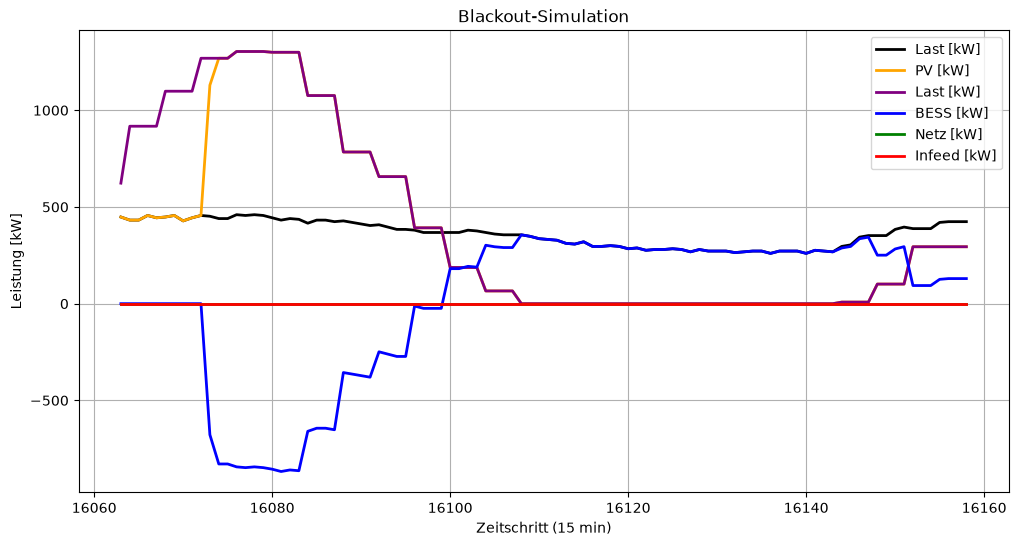

In [43]:
blackout_slice = slice(blackout_start,blackout_start + blackout_steps)
pv_potential = (
    n_up.generators_t.p_max_pu["pv"]
    * n_up.generators.at["pv", "p_nom"]
)
blackout_results = pd.DataFrame({

    "Last [kW]":load_up.iloc[blackout_slice].to_numpy(),
    "PV [kW]":n_up.generators_t.p["pv"].iloc[blackout_slice].to_numpy(),
    "PV-Potenzial [kW]": pv_potential.iloc[blackout_start:blackout_start + blackout_steps].to_numpy(),
    "BESS [kW]":n_up.storage_units_t.p["Batteriespeicher"].iloc[blackout_slice].to_numpy(),
    "SOC [kWh]":n_up.storage_units_t.state_of_charge["Batteriespeicher"].iloc[blackout_slice].to_numpy(),
    "Netz [kW]":n_up.generators_t.p["grid_power"].iloc[blackout_slice].to_numpy(),
    "Infeed [kW]":-n_up.generators_t.p["infeed"].iloc[blackout_slice].to_numpy()})

blackout_results.index = n_up.snapshots[blackout_slice]
blackout_results.index.name = "Zeitschritt"
display(blackout_results.style.format({
        "Last [kW]": lambda x: f"{x:,.0f}".replace(",", "."),
        "PV [kW]": lambda x: f"{abs(x):,.0f}".replace(",", "."),
        "BESS [kW]": lambda x: f"{x:,.0f}".replace(",", "."),
        "SOC [kWh]": lambda x: f"{x:,.0f}".replace(",", "."),
        "Netz [kW]": lambda x: f"{abs(x):,.0f}".replace(",", "."),
        "Infeed [kW]": lambda x: f"{x:,.0f}".replace(",", ".")}))

#blackout_results.to_csv("blackout_results.csv")

plt.figure(figsize=(12, 6))
plt.plot(blackout_results.index, blackout_results["Last [kW]"], label="Last [kW]", color="black", linewidth=2)
plt.plot(blackout_results.index, blackout_results["PV [kW]"], label="PV [kW]", color="orange", linewidth=2)
plt.plot(blackout_results.index, blackout_results["PV-Potenzial [kW]"], label="Last [kW]", color="purple", linewidth=2)
plt.plot(blackout_results.index, blackout_results["BESS [kW]"], label="BESS [kW]", color="blue", linewidth=2)
plt.plot(blackout_results.index, blackout_results["Netz [kW]"], label="Netz [kW]", color="green", linewidth=2)
plt.plot(blackout_results.index, blackout_results["Infeed [kW]"], label="Infeed [kW]", color="red", linewidth=2)
plt.title("Blackout-Simulation")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")
plt.legend()
plt.grid(True)
plt.show()

### Zusammenfassung Blackout

In [44]:
dt_h = 0.25
blackout_slice = slice(blackout_start,blackout_start + blackout_steps)
load_blackout = (n_up.loads_t.p["electrical_load"].iloc[blackout_slice])
pv_blackout = (n_up.generators_t.p["pv"].iloc[blackout_slice])
bess_blackout = (n_up.storage_units_t.p["Batteriespeicher"].iloc[blackout_slice])
grid_blackout = (n_up.generators_t.p["grid_power"].iloc[blackout_slice])

# Energie
energy_load = load_blackout.sum() * dt_h
energy_pv = pv_blackout.sum() * dt_h
energy_bess_discharge = (bess_blackout.clip(lower=0).sum()* dt_h)
energy_bess_charge = (-bess_blackout.clip(upper=0).sum()* dt_h)
energy_grid = grid_blackout.sum() * dt_h

print(f"Last:             "f"{energy_load:,.0f} kWh".replace(",", "."))
print(f"PV:               "f"{energy_pv:,.0f} kWh".replace(",", "."))
print(f"BESS Entladung:   "f"{energy_bess_discharge:,.0f} kWh".replace(",", "."))
print(f"BESS Ladung:      "f"{energy_bess_charge:,.0f} kWh".replace(",", "."))
print(f"Netz:             "f"{energy_grid:,.0f} kWh".replace(",", "."))


Last:             8.686 kWh
PV:               8.418 kWh
BESS Entladung:   3.863 kWh
BESS Ladung:      3.594 kWh
Netz:             0 kWh


### Technische Überprüfung der FCR-Bereitstellung

In [45]:
p_fcr_opt = (n_up.model.variables["P_FCR"].solution.item())
print("Optimale FCR-Leistung:",f"{p_fcr_opt:,.0f}".replace(",", "."),"kW")
fcr_discharge_opt = (af_positive * p_fcr_opt)
fcr_charge_opt = (af_negative * p_fcr_opt)

fcr_discharge_opt = (af_positive * p_fcr_opt)
fcr_charge_opt = (af_negative * p_fcr_opt)
print("Maximale FCR-Entladung:",f"{fcr_discharge_opt.max():,.0f}".replace(",", "."),"kW")
print("Maximale FCR-Ladung:",f"{fcr_charge_opt.max():,.0f}".replace(",", "."),"kW")

fcr_discharge_energy = (fcr_discharge_opt.sum()* dt_h)
fcr_charge_energy = (fcr_charge_opt.sum()* dt_h)
print("FCR-Entladeenergie:",f"{fcr_discharge_energy:,.0f}".replace(",", "."),"kWh")
print("FCR-Ladeenergie:",f"{fcr_charge_energy:,.0f}".replace(",", "."),"kWh")

results_fcr = pd.DataFrame({
    "Frequenz [Hz]":fcr_freq["frequency_mean_Hz"].to_numpy(),
    "FCR Entladen [kW]":fcr_discharge_opt.to_numpy(),
    "FCR Laden [kW]":fcr_charge_opt.to_numpy(),
    "Gesamt BESS [kW]":n_up.storage_units_t.p["Batteriespeicher"].to_numpy(),
    "SOC [kWh]":n_up.storage_units_t.state_of_charge["Batteriespeicher"].to_numpy()})

results_fcr.index = n_up.snapshots
display(results_fcr.head(20).style.format({
        "Frequenz [Hz]": lambda x: f"{x:.2f}".replace(".", ","),
        "FCR Entladen [kW]": lambda x: f"{x:,.0f}".replace(",", "."),
        "FCR Laden [kW]": lambda x: f"{x:,.0f}".replace(",", "."),
        "Gesamt BESS [kW]": lambda x: f"{x:,.0f}".replace(",", "."),
        "SOC [kWh]": lambda x: f"{x:,.0f}".replace(",", ".")}))

Optimale FCR-Leistung: 2.805 kW
Maximale FCR-Entladung: 1.574 kW
Maximale FCR-Ladung: 1.161 kW
FCR-Entladeenergie: 507.700 kWh
FCR-Ladeenergie: 486.374 kWh


,Frequenz [Hz],FCR Entladen [kW],FCR Laden [kW],Gesamt BESS [kW],SOC [kWh]
snapshot,,,,,
0,"49,96",393,0,290,10.475
1,"50,00",34,30,4,10.473
2,"50,00",35,50,-15,10.475
3,"50,01",0,49,-49,10.486
4,"50,00",24,12,12,10.482
5,"50,01",5,29,-24,10.488
6,"50,01",1,37,-36,10.496
7,"50,01",0,90,-90,10.516
8,"50,00",25,4,22,10.510


### Leistungsaufteilung des BESS: Normalbetrieb und FCR

In [46]:
normal_power_available = bess_power_opt - p_fcr_opt
print("FCR-Leistung:",f"{p_fcr_opt:,.0f}".replace(",", "."),"kW")
print("Verbleibende normale BESS-Leistung:",f"{normal_power_available:,.0f}".replace(",", "."),"kW")

normal_dispatch_result = (n_up.model.variables["BESS_normal_dispatch"].solution.to_pandas())
normal_charge_result = (n_up.model.variables["BESS_normal_charge"].solution.to_pandas())
print("Max. normales Entladen:",f"{normal_dispatch_result.iloc[~blackout_mask].max():,.0f}".replace(",", "."),"kW")
print("Max. normales Laden:",f"{normal_charge_result.iloc[~blackout_mask].max():,.0f}".replace(",", "."),"kW")

soc = n_up.storage_units_t.state_of_charge["Batteriespeicher"]
print("Minimaler SOC im Jahr:",f"{soc.min():,.0f}".replace(",", "."),"kWh")
print("Maximaler SOC im Jahr:",f"{soc.max():,.0f}".replace(",", "."),"kWh")
print("SOC vor Blackout:",f"{soc.iloc[blackout_start - 1]:,.0f}".replace(",", "."),"kWh")
print("SOC-Anteil:",f"{soc_before_blackout/ bess_capacity_opt* 100:,.1f}".replace(",", "."),"%")
print("Minimaler SOC im Blackout:",f"{soc.iloc[blackout_start:blackout_start + blackout_steps].min():,.0f}".replace(",", "."),"kWh")
print("Maximaler SOC im Blackout:",f"{soc.iloc[blackout_start:blackout_start + blackout_steps].max():,.0f}".replace(",", "."),"kWh")

soc_before_blackout = (n_up.storage_units_t.state_of_charge["Batteriespeicher"].iloc[blackout_start - 1])

check_fcr = pd.DataFrame({
    "Normal Entladen [kW]":normal_dispatch_result,
    "Normal Laden [kW]":normal_charge_result,
    "FCR Entladen [kW]":fcr_discharge_opt.to_numpy(),
    "FCR Laden [kW]":fcr_charge_opt.to_numpy(),
    "BESS netto [kW]":n_up.storage_units_t.p["Batteriespeicher"].to_numpy(),
    "SOC [kWh]":n_up.storage_units_t.state_of_charge["Batteriespeicher"].to_numpy()})

check_fcr.index = n_up.snapshots
display(check_fcr.head(20).style.format(lambda x: f"{x:,.0f}".replace(",", ".")))

FCR-Leistung: 2.805 kW
Verbleibende normale BESS-Leistung: 195 kW
Max. normales Entladen: 195 kW
Max. normales Laden: 195 kW
Minimaler SOC im Jahr: 7.778 kWh
Maximaler SOC im Jahr: 12.000 kWh
SOC vor Blackout: 8.686 kWh
SOC-Anteil: 72.4 %
Minimaler SOC im Blackout: 7.810 kWh
Maximaler SOC im Blackout: 12.000 kWh


,Normal Entladen [kW],Normal Laden [kW],FCR Entladen [kW],FCR Laden [kW],BESS netto [kW],SOC [kWh]
snapshot,,,,,,
0,0,103,393,0,290,10.475
1,0,0,34,30,4,10.473
2,0,0,35,50,-15,10.475
3,0,0,0,49,-49,10.486
4,0,0,24,12,12,10.482
5,0,0,5,29,-24,10.488
6,0,0,1,37,-36,10.496
7,0,0,0,90,-90,10.516
8,0,0,25,4,22,10.510


### Ergebnisse des PyPSA-Netzwerks

### Jahresenergiebilanz des Upgrade-Systems

In [47]:
dt_h = 0.25

# PV-Erzeugung (tatsächlich)
pv_energy_kwh = (n_up.generators_t.p["pv"].clip(lower=0).sum()* dt_h)

# PV-Erzeugungspotenzial
pv_potential = (n_up.generators_t.p_max_pu["pv"]* n_up.generators.at["pv", "p_nom"])
pv_potential_kwh = (pv_potential.sum()* dt_h)

# PV-Abregelung
pv_curtailment_kwh = (pv_potential_kwh- pv_energy_kwh)

# Netzeinspeisung
feed_in_energy_kwh = (n_up.generators_t.p["infeed"].clip(lower=0).sum()* dt_h)

# Netzbezug
grid_import_kwh = (n_up.generators_t.p["grid_power"].clip(lower=0).sum()* dt_h)

# Krankenhauslast
load_energy_kwh = (n_up.loads_t.p["electrical_load"].sum()* dt_h)

# Batterie
bess_charge_kwh = (n_up.storage_units_t.p_store["Batteriespeicher"].sum()* dt_h)
bess_discharge_kwh = (n_up.storage_units_t.p_dispatch["Batteriespeicher"].sum()* dt_h)

# PV-Eigenverbrauch
pv_self_consumption_kwh = (pv_energy_kwh- feed_in_energy_kwh)

# PV-Eigenverbrauchsanteil
self_consumption_share = (pv_self_consumption_kwh/ pv_energy_kwh* 100
    if pv_energy_kwh > 0
    else 0)

# PV-Einspeiseanteil
feed_in_share = (feed_in_energy_kwh/ pv_energy_kwh* 100
    if pv_energy_kwh > 0
    else 0)

# PV-Abregelungsanteil
curtailment_share = (pv_curtailment_kwh/ pv_potential_kwh* 100
    if pv_potential_kwh > 0
    else 0)

energy_balance = pd.DataFrame({
    "Kennzahl": ["Krankenhausverbrauch","Netzbezug","PV-Potenzial","PV-Erzeugung","PV-Abregelung",
                 "Netzeinspeisung","PV-Eigenverbrauch","BESS-Ladung","BESS-Entladung",
                 "PV-Eigenverbrauchsanteil","PV-Einspeiseanteil","PV-Abregelungsanteil"],

    "Wert": [load_energy_kwh,grid_import_kwh,pv_potential_kwh,pv_energy_kwh,pv_curtailment_kwh,
             feed_in_energy_kwh,pv_self_consumption_kwh,bess_charge_kwh,bess_discharge_kwh,
             self_consumption_share,feed_in_share,curtailment_share],

    "Einheit": ["kWh/a","kWh/a","kWh/a","kWh/a","kWh/a","kWh/a","kWh/a","kWh/a","kWh/a","%","%","%"]})

display(energy_balance.style.format({"Wert": lambda x: f"{x:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")}))

,Kennzahl,Wert,Einheit
0,Krankenhausverbrauch,3.361.632,kWh/a
1,Netzbezug,2.132.016,kWh/a
2,PV-Potenzial,1.811.664,kWh/a
3,PV-Erzeugung,1.810.251,kWh/a
4,PV-Abregelung,1.413,kWh/a
5,Netzeinspeisung,451.278,kWh/a
6,PV-Eigenverbrauch,1.358.973,kWh/a
7,BESS-Ladung,862.860,kWh/a
8,BESS-Entladung,733.504,kWh/a
9,PV-Eigenverbrauchsanteil,75,%


### BESS-Durchsatz und Degradationskosten

In [48]:
bess_degradation_cost = 0.03  # €/kWh Durchsatz

# Gesamter BESS-Durchsatz
p_dispatch = (n_up.storage_units_t.p_dispatch["Batteriespeicher"])
p_store = (n_up.storage_units_t.p_store["Batteriespeicher"])
annual_throughput = ((p_dispatch + p_store).sum()* dt_h)
annual_degradation_cost = (annual_throughput* bess_degradation_cost)

# FCR-Durchsatz
fcr_throughput = ((fcr_discharge_opt.sum()+ fcr_charge_opt.sum())* dt_h)
fcr_degradation_cost = (fcr_throughput* bess_degradation_cost)

# Normaler BESS-Durchsatz
normal_dispatch_result = (n_up.model.variables["BESS_normal_dispatch"].solution.to_pandas())
normal_charge_result = (n_up.model.variables["BESS_normal_charge"].solution.to_pandas())
normal_throughput = ((normal_dispatch_result.sum()+ normal_charge_result.sum())* dt_h)
normal_degradation_cost = (normal_throughput* bess_degradation_cost)


def format_de(value):
    return f"{value:,.0f}".replace(",", ".")

print("Gesamt-BESS-Durchsatz:", format_de(annual_throughput), "kWh/a")
print("FCR-Durchsatz:", format_de(fcr_throughput), "kWh/a")
print("Normalbetrieb-Durchsatz:", format_de(normal_throughput), "kWh/a")
print("Gesamt-Degradationskosten:", format_de(annual_degradation_cost), "€/a")
print("FCR-Degradationskosten:", format_de(fcr_degradation_cost), "€/a")
print("Normalbetrieb-Degradationskosten:", format_de(normal_degradation_cost), "€/a")

Gesamt-BESS-Durchsatz: 1.596.364 kWh/a
FCR-Durchsatz: 994.074 kWh/a
Normalbetrieb-Durchsatz: 602.290 kWh/a
Gesamt-Degradationskosten: 47.891 €/a
FCR-Degradationskosten: 29.822 €/a
Normalbetrieb-Degradationskosten: 18.069 €/a


### Überprüfung der FCR-SOC-Reservegrenzen

In [49]:
soc = n_up.storage_units_t.state_of_charge["Batteriespeicher"]
soc_normal = soc.iloc[~blackout_mask]
print("Minimaler SOC außerhalb Blackout:",f"     {soc_normal.min():,.0f}","kWh")
print("Maximaler SOC außerhalb Blackout:",f"     {soc_normal.max():,.0f}".replace(",", "."),"kWh")

# Wirkungsgrade für Auswertung
eta_store = n_up.storage_units.at["Batteriespeicher","efficiency_store"]
eta_dispatch = n_up.storage_units.at["Batteriespeicher","efficiency_dispatch"]

# Gleiche angenommene FCR-Energiereserve wie in der Optimierungsfunktion
fcr_energy_duration_h = 0.25

soc_lower_theoretical = (p_fcr_opt* fcr_energy_duration_h/ eta_dispatch)
soc_upper_theoretical = (bess_capacity_opt- p_fcr_opt* fcr_energy_duration_h* eta_store)
print("Theoretische untere FCR-SOC-Grenze:",f"   {soc_lower_theoretical:,.0f}","kWh")
print("Theoretische obere FCR-SOC-Grenze:",f"    {soc_upper_theoretical:,.0f}".replace(",", "."),"kWh")

Minimaler SOC außerhalb Blackout:      7,778 kWh
Maximaler SOC außerhalb Blackout:      11.353 kWh
Theoretische untere FCR-SOC-Grenze:    761 kWh
Theoretische obere FCR-SOC-Grenze:     11.353 kWh


### Optimale FCR-Leistung und Kapazitätserlös

In [50]:
p_fcr_opt = (n_up.model.variables["P_FCR"].solution.item())
print("Optimale FCR-Leistung:",f"{p_fcr_opt:,.0f}".replace(",", "."),"kW")

fcr_revenue_opt = (p_fcr_opt* fcr_revenue_per_kw)
print("FCR-Kapazitätserlös:",f"{fcr_revenue_opt:,.0f}".replace(",", "."),"€/a")

Optimale FCR-Leistung: 2.805 kW
FCR-Kapazitätserlös: 423.536 €/a


>## **Auswertung**

### Energetische Auswertung

In [51]:
#grid_supply_up = n_up.generators_t.p['grid_power']
#battery_soc = n_up.storage_units_t.state_of_charge['Batteriespeicher']
#battery_capacity = n_up.storage_units.loc['Batteriespeicher','p_nom']*max_hours
#battery_capacity_t = battery_soc * battery_capacity
#battery_charge = n_up.storage_units_t.p_store['Batteriespeicher']
#battery_discharge = n_up.storage_units_t.p_dispatch['Batteriespeicher']
#battery_capital = bess_capex_total
#print(battery_capital)


#### Energie-Bezug & Maximale Last

C:\Users\jlemm\AppData\Local\Temp\ipykernel_5200\3090520600.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


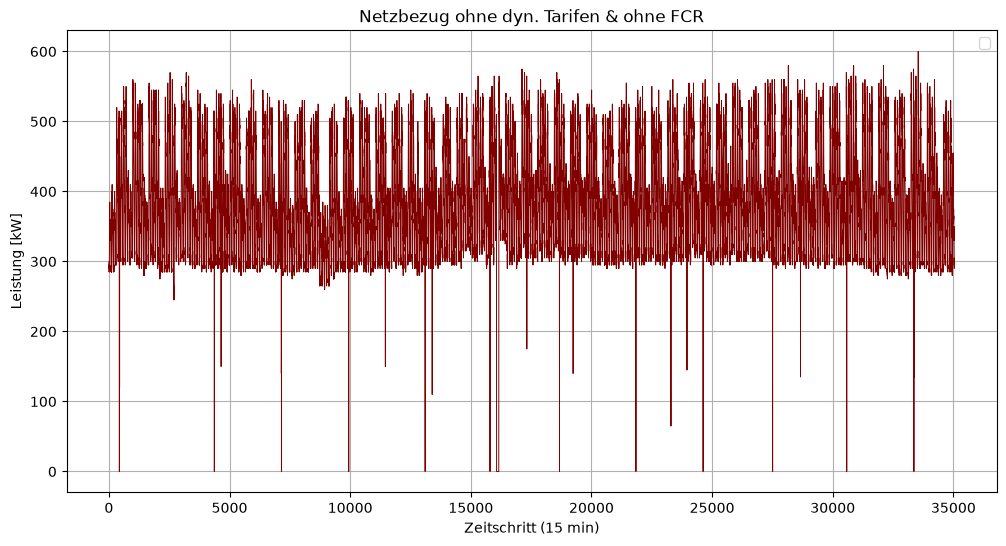

In [204]:
plt.figure(figsize=(12, 6))
plt.plot(n_is.generators_t.p['grid_power'].clip(0),
    color=(128/255,0/255,0/255),
    linewidth=0.7)
#plt.plot(grid_supply_up, label='Last "Upgrade ohne FCR" [kW]', color="green", linewidth=0.5)
#plt.plot(n_up.generators_t.p['grid_power'], label='Last "Upgrade mit FCR" [kW]', color="red", linewidth=0.2)
plt.title("Netzbezug ohne dyn. Tarifen & ohne FCR")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")
plt.legend()
plt.grid(True)
plt.show()

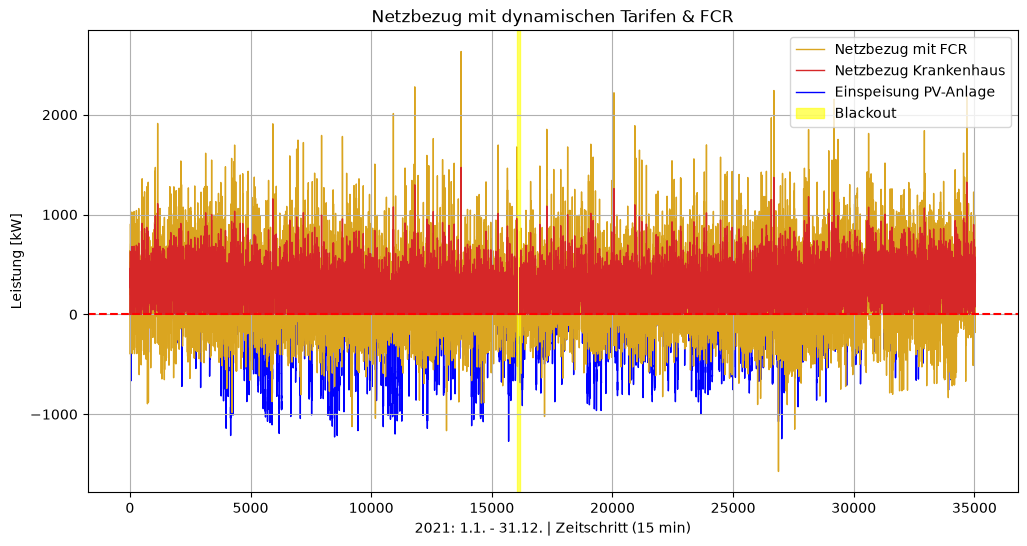

In [205]:
grid_import = n_up.generators_t.p['grid_power']

blackout_end = blackout_start + blackout_steps

#grid_export = results_fcr["FCR Entladen [kW]"]

#net_grid = grid_import - grid_export

grid = results_fcr["FCR Laden [kW]"] - results_fcr["FCR Entladen [kW]"] + n_up.generators_t.p['grid_power']

plt.figure(figsize=(12, 6))

plt.plot(
    grid,
    color='goldenrod',
    linewidth=1.0,
    zorder=1,
    label='Netzbezug mit FCR'
)

plt.plot(
    grid_import,
    color="tab:red",
    linewidth=1.0,
    zorder=2,
    label='Netzbezug Krankenhaus'
)

plt.plot(
    -n_up.generators_t.p["infeed"],
    color="blue",
    linewidth=1.0,
    zorder=0,
    label='Einspeisung PV-Anlage'
)

plt.axhline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--'
)

plt.axvspan(
    blackout_start,
    blackout_end,
    color='yellow',
    alpha=0.6,
    label='Blackout'
)

plt.title("Netzbezug mit dynamischen Tarifen & FCR")
plt.xlabel("2021: 1.1. - 31.12. | Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")

plt.legend()

plt.grid(True)
plt.show()

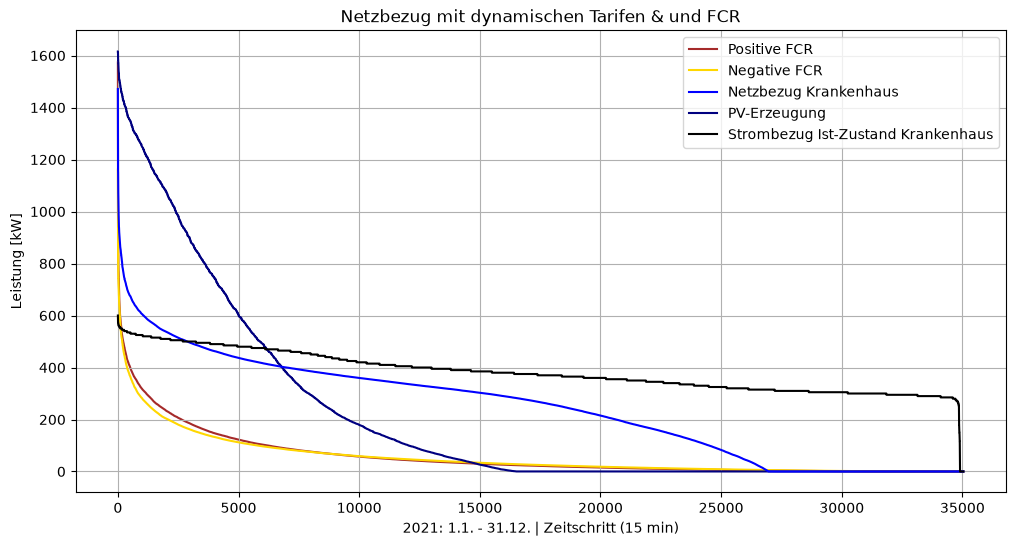

In [183]:
grid_import = n_up.generators_t.p['grid_power']


#grid_export = results_fcr["FCR Entladen [kW]"]

#net_grid = grid_import - grid_export

grid = results_fcr["FCR Laden [kW]"]-results_fcr["FCR Entladen [kW]"]+n_up.generators_t.p['grid_power'] 

plt.figure(figsize=(12, 6))

plt.plot(results_fcr["FCR Entladen [kW]"].sort_values(ascending=False).reset_index(drop=True),
    color='brown',
    linewidth=1.5,
    zorder=1,
    label='Positive FCR')

plt.plot(results_fcr["FCR Laden [kW]"].sort_values(ascending=False).reset_index(drop=True),
    color='gold',
    linewidth=1.5,
    zorder=2,
    label='Negative FCR')

plt.plot(grid_import.sort_values(ascending=False).reset_index(drop=True),
    color='blue',
    linewidth=1.5,
    zorder=4,
    label='Netzbezug Krankenhaus')

plt.plot(n_up.generators_t.p['pv'].sort_values(ascending=False).reset_index(drop=True),
    color='Navy',
    linewidth=1.5,
    zorder=3,
    label='PV-Erzeugung')

plt.plot(n_is.generators_t.p['grid_power'].sort_values(ascending=False).reset_index(drop=True),
    color='Black',
    linewidth=1.5,
    zorder=5,
    label='Strombezug Ist-Zustand Krankenhaus')


#plt.plot(-n_up.generators_t.p['infeed'],
#    color='blue',
#    linewidth=1.0,
#    zorder=1)

#plt.axhline(0, color='red',
#            linewidth=1.5,
#            linestyle ='--')

#plt.plot(results_fcr["FCR Entladen [kW]"], label='Bereitgestelle "Positive FCR" [kW]', color="green", linewidth=0.5)
#plt.plot(results_fcr["FCR Laden [kW]"], label='Bereitgestelle "Negative FCR" [kW]', color="green", linewidth=0.5)
#plt.plot(grid_import, label='Netzbezug des Krankenhauses', color="red", linewidth=0.2)
plt.title("Netzbezug mit dynamischen Tarifen & und FCR")
plt.xlabel("2021: 1.1. - 31.12. | Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [59]:
#### Ausgabe d. Lastprofile als .csv
heute = datetime.now().strftime("%Y-%m-%d")
#n_up.generators_t.p['grid_power'].to_csv("Last Krankenhaus FCR & dyn. Stromtarife"+ heute + ".csv")

#grid.to_csv("Lastfluss NAP Krankenhaus FCR & dyn. Stromtarife"+ heute + ".csv")

#### Verhalten Batterie im Regelbetrieb

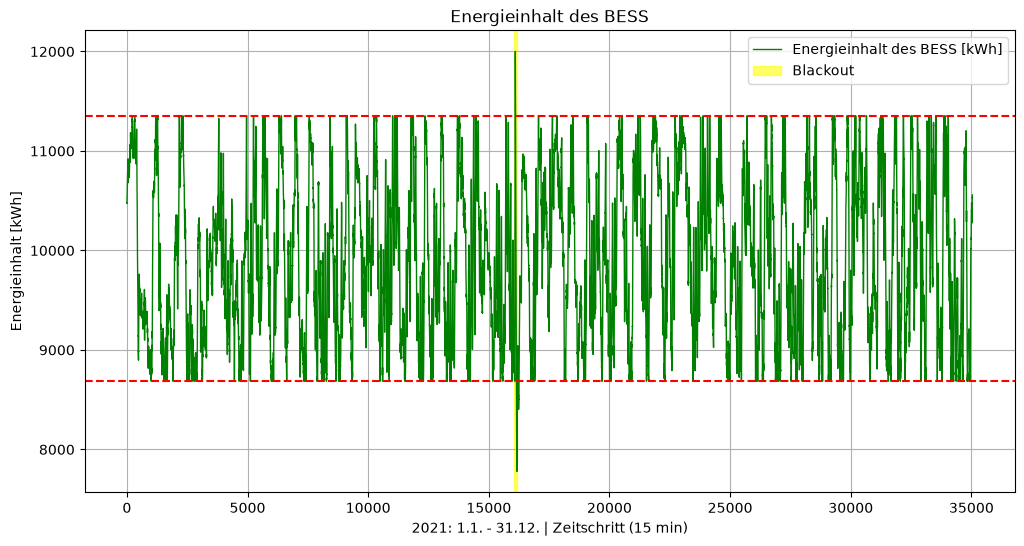

In [206]:
# SOC Batterie

plt.figure(figsize=(12, 6))

#plt.plot(grid,
#    color='goldenrod',
#    linewidth=1.0,
#    zorder=1)

#plt.plot(results_fcr["FCR Laden [kW]"],
#    color='goldenrod',
#    linewidth=1.0,
#    zorder=1)

plt.plot(soc,
    color='green',
    linewidth=1.0,
    zorder=2,
    label='Energieinhalt des BESS [kWh]')

#plt.plot(-n_up.generators_t.p['infeed'],
#    color='blue',
#    linewidth=1.0,
#    zorder=1)

plt.axhline(max_energy * 0.8, color='red',
            linewidth=1.5,
            linestyle ='--')

plt.axhline(soc_upper_theoretical, color='red',
            linewidth=1.5,
            linestyle ='--')


plt.axvspan(
    blackout_start,
    blackout_end,
    color='yellow',
    alpha=0.6,
    label='Blackout'
)

#plt.plot(grid_supply_up, label='Last "Upgrade ohne FCR" [kW]', color="green", linewidth=0.5)
#plt.plot(n_up.generators_t.p['grid_power'], label='Last "Upgrade mit FCR" [kW]', color="red", linewidth=0.2)
plt.title("Energieinhalt des BESS")
plt.xlabel("2021: 1.1. - 31.12. | Zeitschritt (15 min)")
plt.ylabel("Energieinhalt [kWh]")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\jlemm\AppData\Local\Temp\ipykernel_5200\2574750240.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


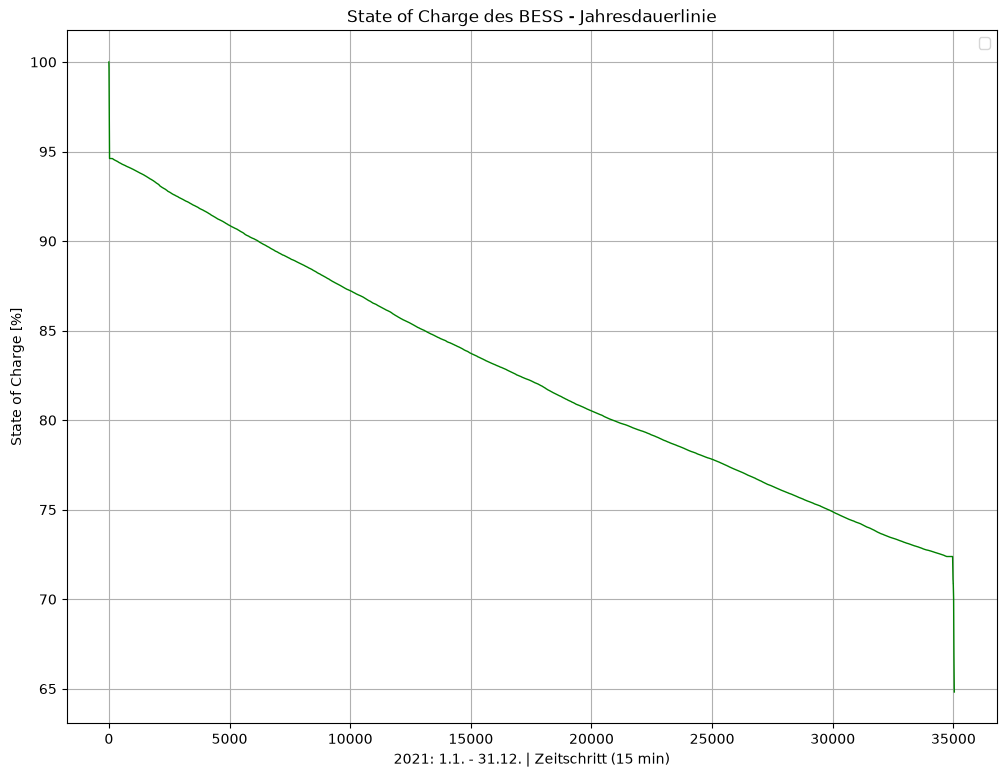

In [62]:
#SOC

soc_pu = 100*soc/(max_hours*n_up.storage_units.at['Batteriespeicher', 'p_nom_opt'])


plt.figure(figsize=(12, 9))

#plt.plot(grid,
#    color='goldenrod',
#    linewidth=1.0,
#    zorder=1)

#plt.plot(results_fcr["FCR Laden [kW]"],
#    color='goldenrod',
#    linewidth=1.0,
#    zorder=1)

plt.plot(soc_pu.sort_values(ascending=False).reset_index(drop=True),
    color='green',
    linewidth=1.0,
    zorder=2)

#plt.plot(-n_up.generators_t.p['infeed'],
#    color='blue',
#    linewidth=1.0,
#    zorder=1)

#plt.plot(grid_supply_up, label='Last "Upgrade ohne FCR" [kW]', color="green", linewidth=0.5)
#plt.plot(n_up.generators_t.p['grid_power'], label='Last "Upgrade mit FCR" [kW]', color="red", linewidth=0.2)
plt.title("State of Charge des BESS - Jahresdauerlinie")
plt.xlabel("2021: 1.1. - 31.12. | Zeitschritt (15 min)")
plt.ylabel("State of Charge [%]")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Lade- & Entladeverhalten über Last

#### Notstrom-Verhalten

C:\Users\jlemm\AppData\Local\Temp\ipykernel_5200\678336986.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


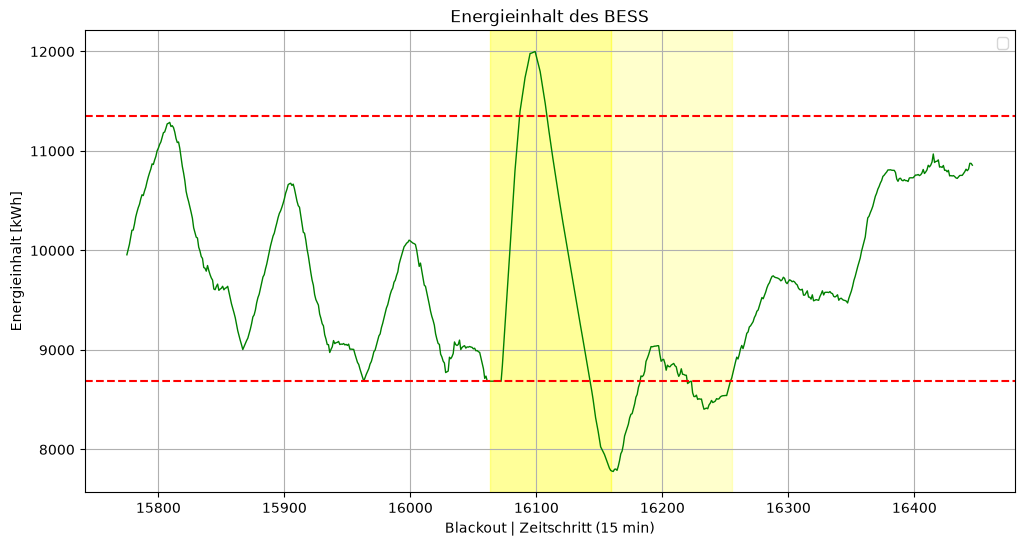

In [209]:
blackout_end = blackout_start + blackout_steps

#SOC

plt.figure(figsize=(12, 6))

#plt.plot(grid,
#    color='goldenrod',
#    linewidth=1.0,
#    zorder=1)

#plt.plot(results_fcr["FCR Laden [kW]"],
#    color='goldenrod',
#    linewidth=1.0,
#    zorder=1)

plt.plot(soc.iloc[blackout_start-3*blackout_steps:blackout_end + 3 * blackout_steps],
    color='green',
    linewidth=1.0,
    zorder=2)

#plt.plot(-n_up.generators_t.p['infeed'],
#    color='blue',
#    linewidth=1.0,
#    zorder=1)

plt.axhline(max_energy * 0.8,
            color='red',
            linewidth=1.5,
            linestyle ='--')

plt.axhline(soc_upper_theoretical, color='red',
            linewidth=1.5,
            linestyle ='--')

plt.axvspan(blackout_start,
            blackout_end,
            color='yellow',
            alpha=0.4)

plt.axvspan(blackout_end,
            blackout_end + blackout_steps,
            color='yellow',
            alpha=0.2)

#plt.plot(grid_supply_up, label='Last "Upgrade ohne FCR" [kW]', color="green", linewidth=0.5)
#plt.plot(n_up.generators_t.p['grid_power'], label='Last "Upgrade mit FCR" [kW]', color="red", linewidth=0.2)
plt.title("Energieinhalt des BESS")
plt.xlabel("Blackout | Zeitschritt (15 min)")
plt.ylabel("Energieinhalt [kWh]")
plt.legend()
plt.grid(True)
plt.show()

### Wirtschaftliche Auswertung

In [67]:
bess_capacity_opt = (
    n_up.storage_units.at["Batteriespeicher", "p_nom_opt"]
    * n_up.storage_units.at["Batteriespeicher", "max_hours"]
)

xp = [1000, 3500, 7000, 10000]
fp = [360, 310, 285, 273]

selected_cost_per_kwh = np.interp(
    bess_capacity_opt,
    xp,
    fp
)

bess_capex_total = bess_capacity_opt * selected_cost_per_kwh

interest_rate = 0.02
lifespan = 15

annuity_factor_bess = (
    ((1 + interest_rate)**lifespan) * interest_rate
    / (((1 + interest_rate)**lifespan) - 1)
)

annuity_bess = bess_capex_total * annuity_factor_bess

print(annuity_diesel, annuity_pv,annuity_bess)

0.06115671812529034 0.051220438417394674 254956.24709179957


31483.478490899466 149468.98957069084 254956.24709179957


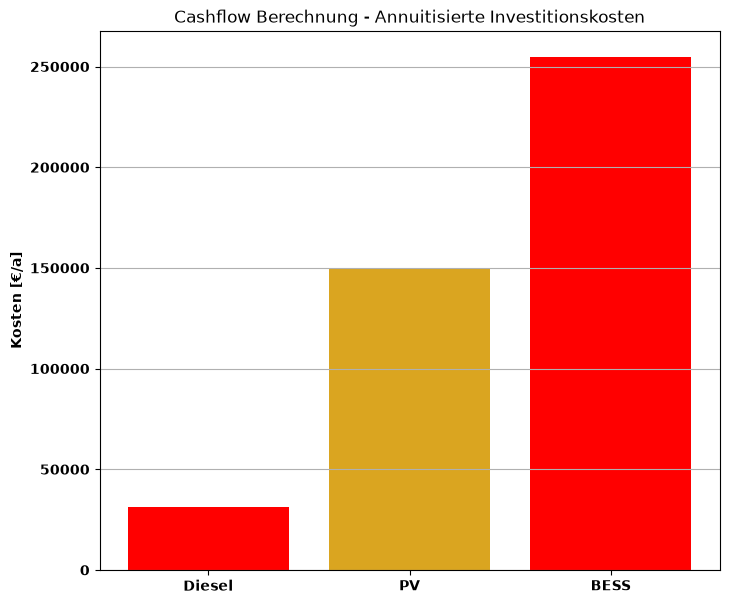

In [178]:
diesel_a = annuity_diesel * capex_diesel * diesel_rated_power

pv_a = pv_capital_cost * pv_peak_power

print(diesel_a, pv_a, annuity_bess)

labels = ["Diesel", "PV", "BESS"]

werte = [diesel_a, pv_a, annuity_bess]

plt.figure(figsize=(8, 7))

plt.bar(labels, werte, color=["red", "goldenrod", "red"])

plt.ylabel("Kosten [€/a]", fontweight="bold")

plt.title("Cashflow Berechnung - Annuitisierte Investitionskosten")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.grid(axis="y")

plt.show()

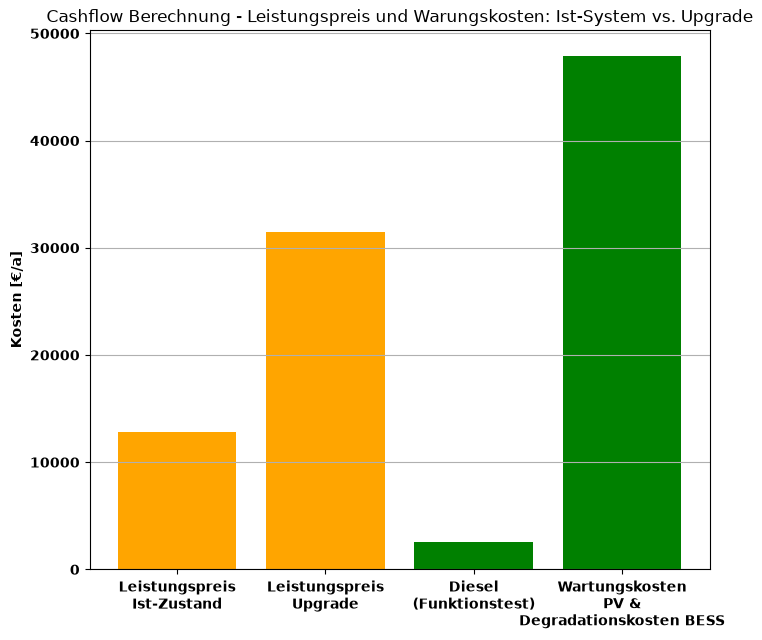

In [ ]:
labels_ax1 = [
    "Leistungspreis\nIst-Zustand",
    "Leistungspreis\nUpgrade",
    "Diesel\n(Funktionstest)",
    "Wartungskosten\nPV &\nDegradationskosten BESS"
]

x1 = np.arange(len(labels_ax1))

plt.figure(figsize=(8, 7))

plt.bar(x1[0], lp_is, color="orange")
plt.bar(x1[1], lp_up, color="orange")

plt.bar(x1[2], ds_is, color="green")
plt.bar(x1[3], es_up, color="green")

plt.xticks(x1, labels_ax1)

plt.ylabel(
    "Kosten [€/a]",
    fontweight="bold"
)

plt.ticklabel_format(style="plain", axis="y")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.title(
    "Cashflow Berechnung - Leistungspreis und Wartungskosten: Ist-System vs. Upgrade"
)

plt.grid(axis="y")

plt.show()

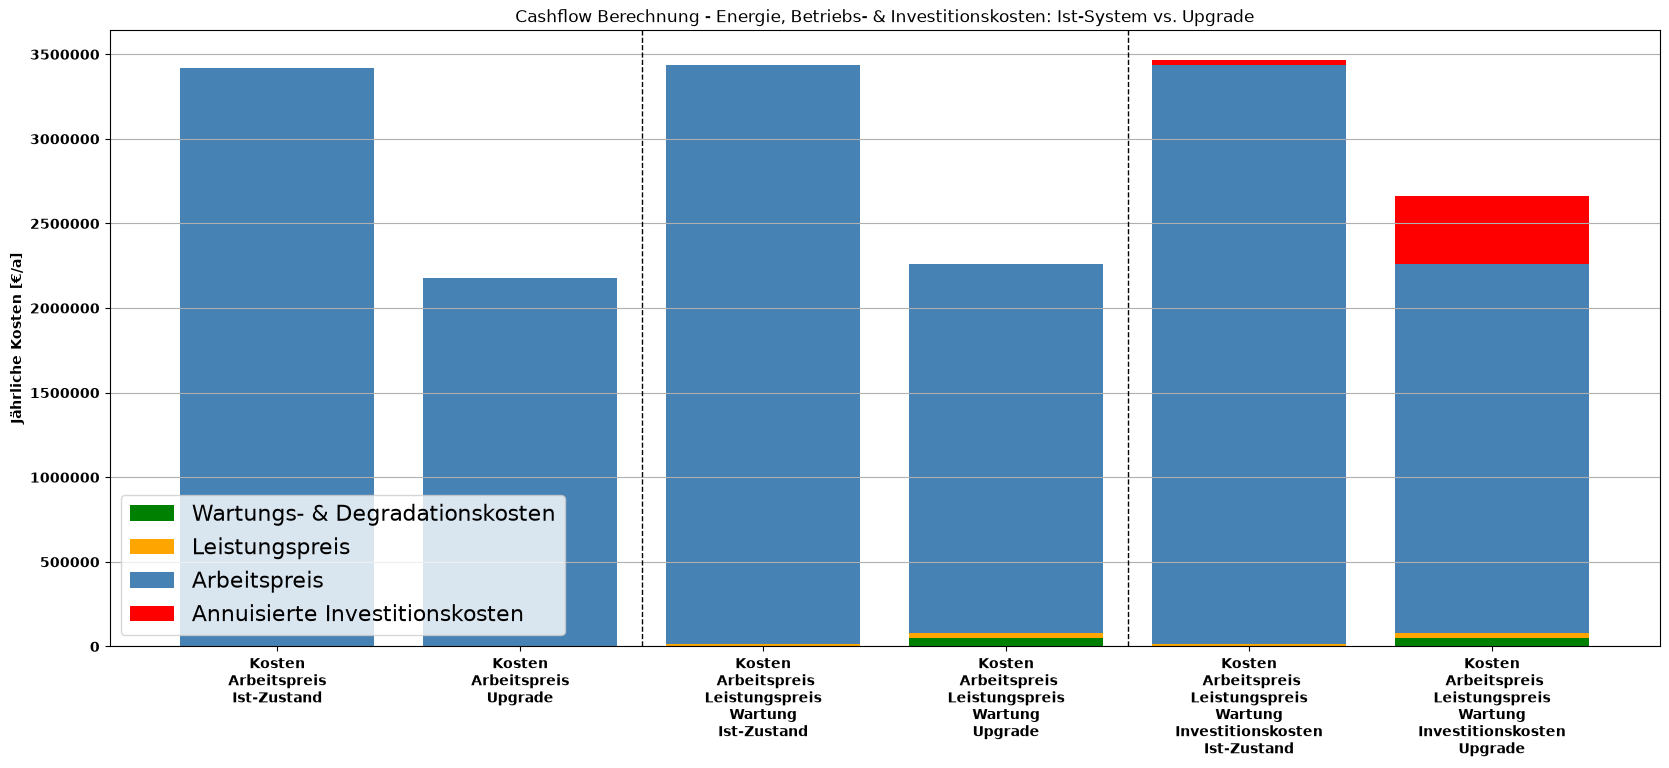

In [242]:
labels_ax2 = [
    "Kosten\nArbeitspreis\nIst-Zustand",
    "Kosten\nArbeitspreis\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nUpgrade",
]

x2 = np.arange(len(labels_ax2))

plt.figure(figsize=(20, 8))

# Arbeitspreis
plt.bar(x2[0], ap_is, color="steelblue")
plt.bar(x2[1], ap_up, color="steelblue")

# Kombinierter Ist-Zustand
plt.bar(x2[2], ds_is, color="green")
plt.bar(x2[2], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[2], ap_is, bottom=ds_is + lp_is, color="steelblue")

# Kombinierter Upgrade-Zustand
plt.bar(x2[3], es_up, color="green", label="Wartungs- & Degradationskosten")
plt.bar(x2[3], lp_up, bottom=es_up, color="orange", label="Leistungspreis")
plt.bar(x2[3], ap_up, bottom=es_up + lp_up, color="steelblue", label="Arbeitspreis")

# Opex & Capex Ist-Zustand
plt.bar(x2[4], ds_is, color="green")
plt.bar(x2[4], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[4], ap_is, bottom=ds_is + lp_is, color="steelblue")
plt.bar(
    x2[4],
    diesel_a,
    bottom=ds_is + lp_is + ap_is,
    color="red"
)

# Opex & Capex Upgrade
plt.bar(x2[5], es_up, color="green")
plt.bar(x2[5], lp_up, bottom=es_up, color="orange")
plt.bar(x2[5], ap_up, bottom=es_up + lp_up, color="steelblue")
plt.bar(
    x2[5],
    pv_a,
    bottom=es_up + lp_up + ap_up,
    color="red"
)
plt.bar(
    x2[5],
    annuity_bess,
    bottom=es_up + lp_up + ap_up + pv_a,
    color="red", label='Annuisierte Investitionskosten'
)

plt.xticks(x2, labels_ax2)

plt.ylabel(
    "Jährliche Kosten [€/a]",
    fontweight="bold"
)

plt.ticklabel_format(style="plain", axis="y")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.title(
    "Cashflow Berechnung - Energie, Betriebs- & Investitionskosten: Ist-System vs. Upgrade"
)

plt.axvline(1.5, color='black', linestyle='--', linewidth=1, alpha=1)
plt.axvline(3.5, color='black', linestyle='--', linewidth=1, alpha=1)

plt.grid(axis="y")

plt.legend(loc='lower left', fontsize = 16)

plt.show()

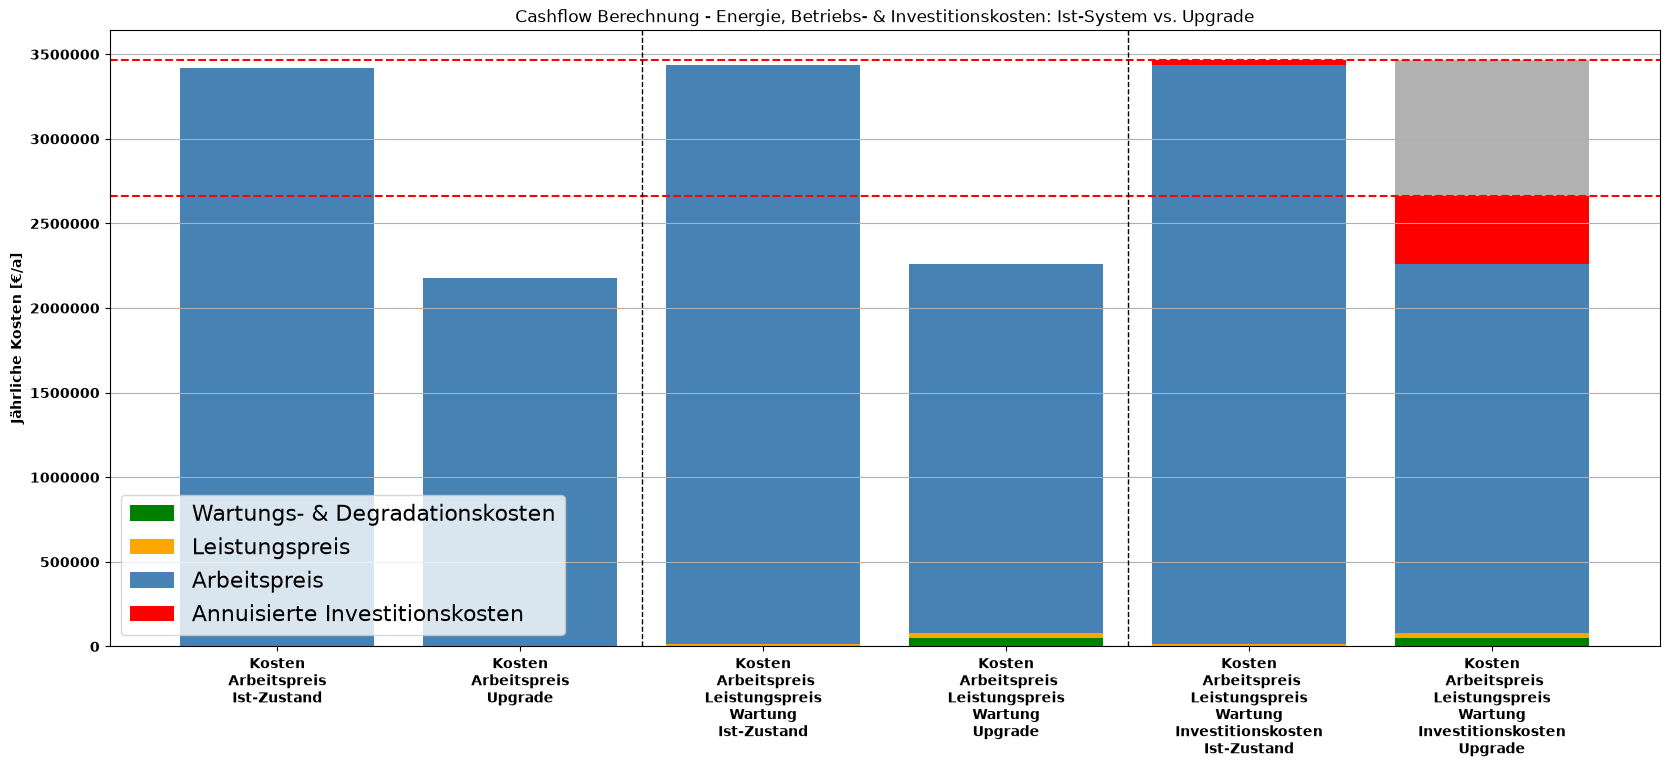

In [240]:
cashflow_is = (ds_is + lp_is + ap_is+diesel_a)

cashflow_up = (es_up + lp_up + ap_up + pv_a + annuity_bess)

cashflow_diff = cashflow_is - cashflow_up

labels_ax2 = [
    "Kosten\nArbeitspreis\nIst-Zustand",
    "Kosten\nArbeitspreis\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nUpgrade",
]

x2 = np.arange(len(labels_ax2))

plt.figure(figsize=(20, 8))

# Arbeitspreis
plt.bar(x2[0], ap_is, color="steelblue")
plt.bar(x2[1], ap_up, color="steelblue")

# Kombinierter Ist-Zustand
plt.bar(x2[2], ds_is, color="green")
plt.bar(x2[2], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[2], ap_is, bottom=ds_is + lp_is, color="steelblue")

# Kombinierter Upgrade-Zustand
plt.bar(x2[3], es_up, color="green", label="Wartungs- & Degradationskosten")
plt.bar(x2[3], lp_up, bottom=es_up, color="orange", label="Leistungspreis")
plt.bar(x2[3], ap_up, bottom=es_up + lp_up, color="steelblue", label="Arbeitspreis")

# Opex & Capex Ist-Zustand
plt.bar(x2[4], ds_is, color="green")
plt.bar(x2[4], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[4], ap_is, bottom=ds_is + lp_is, color="steelblue")
plt.bar(x2[4],diesel_a,bottom=ds_is + lp_is + ap_is,color="red"
)

# Opex & Capex Upgrade
plt.bar(x2[5], es_up, color="green")
plt.bar(x2[5], lp_up, bottom=es_up, color="orange")
plt.bar(x2[5], ap_up, bottom=es_up + lp_up, color="steelblue")
plt.bar(x2[5], pv_a, bottom=es_up + lp_up + ap_up, color="red")
plt.bar(x2[5],annuity_bess,bottom=es_up + lp_up + ap_up + pv_a,color="red", label='Annuisierte Investitionskosten')
plt.bar(x2[5],(ds_is + lp_is + ap_is+diesel_a)-(es_up + lp_up + ap_up + pv_a + annuity_bess),bottom=es_up + lp_up + ap_up + pv_a + annuity_bess,color="grey", alpha=0.6)

plt.xticks(x2, labels_ax2)

plt.axhline(ds_is + lp_is + ap_is+diesel_a,color='red',linewidth=1.5,linestyle ='--')

plt.axhline(es_up + lp_up + ap_up + pv_a+ annuity_bess, color='red',linewidth=1.5,linestyle ='--')

plt.ylabel(
    "Jährliche Kosten [€/a]",
    fontweight="bold"
)

plt.ticklabel_format(style="plain", axis="y")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.title(
    "Cashflow Berechnung - Energie, Betriebs- & Investitionskosten: Ist-System vs. Upgrade"
)

plt.grid(axis="y")

plt.axvline(1.5, color='black', linestyle='--', linewidth=1, alpha=1)
plt.axvline(3.5, color='black', linestyle='--', linewidth=1, alpha=1)

plt.legend(loc='lower left', fontsize = 16)

plt.show()

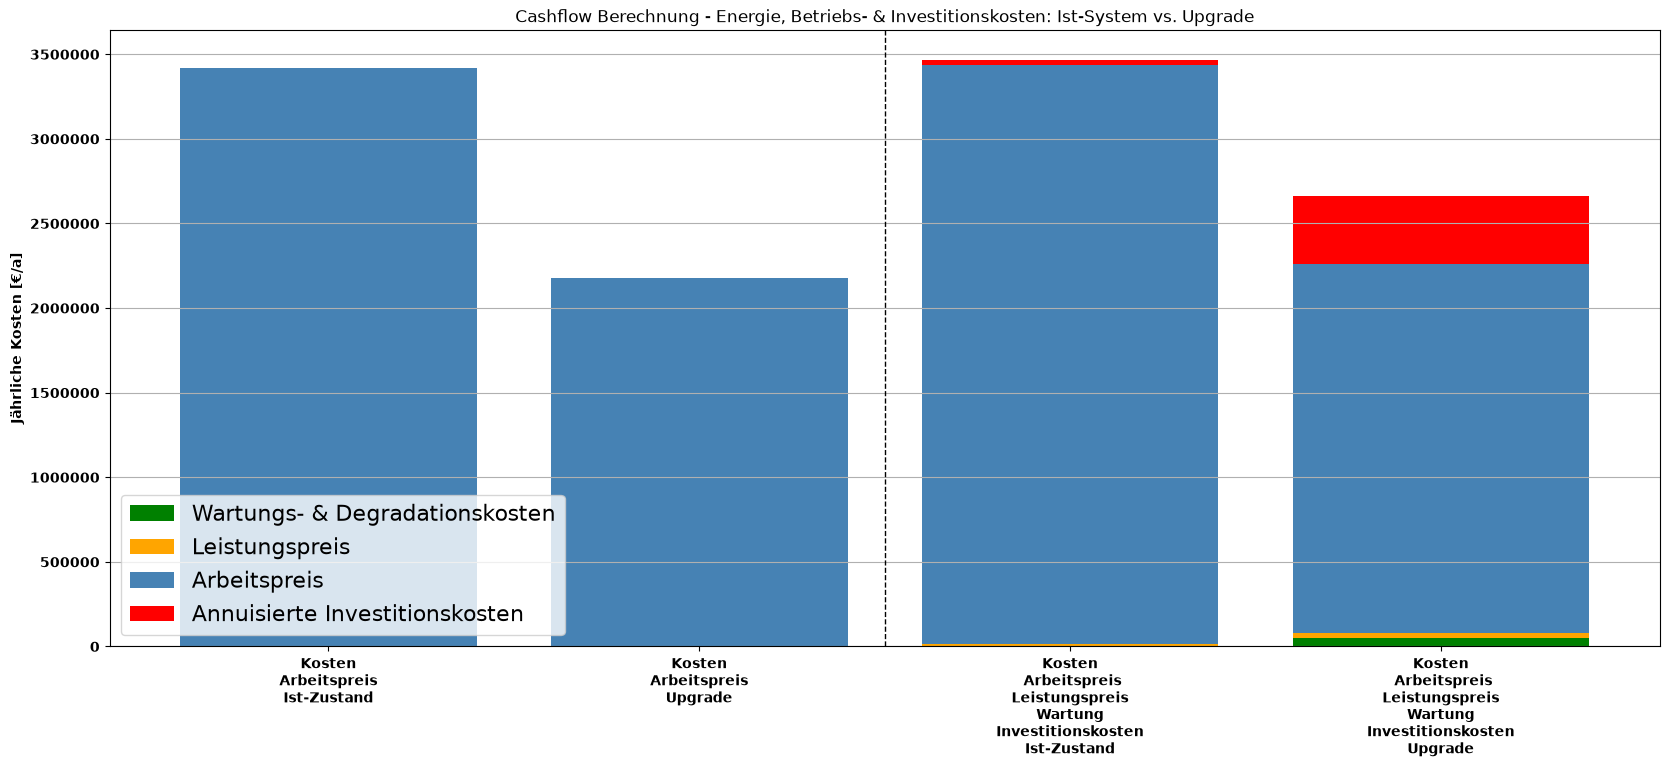

In [243]:
labels_ax2 = [
    "Kosten\nArbeitspreis\nIst-Zustand",
    "Kosten\nArbeitspreis\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nUpgrade",
]

x2 = np.arange(len(labels_ax2))

plt.figure(figsize=(20, 8))

# Arbeitspreis
plt.bar(x2[0], ap_is, color="steelblue")
plt.bar(x2[1], ap_up, color="steelblue")

# Opex & Capex Ist-Zustand
plt.bar(x2[2], ds_is, color="green")
plt.bar(x2[2], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[2], ap_is, bottom=ds_is + lp_is, color="steelblue")
plt.bar(
    x2[2],
    diesel_a,
    bottom=ds_is + lp_is + ap_is,
    color="red"
)

# Opex & Capex Upgrade
plt.bar(x2[3], es_up, color="green", label="Wartungs- & Degradationskosten")
plt.bar(x2[3], lp_up, bottom=es_up, color="orange", label="Leistungspreis")
plt.bar(x2[3], ap_up, bottom=es_up + lp_up, color="steelblue", label="Arbeitspreis")
plt.bar(
    x2[3],
    pv_a,
    bottom=es_up + lp_up + ap_up,
    color="red"
)
plt.bar(
    x2[3],
    annuity_bess,
    bottom=es_up + lp_up + ap_up + pv_a,
    color="red", label='Annuisierte Investitionskosten'
)

plt.xticks(x2, labels_ax2)

plt.ylabel(
    "Jährliche Kosten [€/a]",
    fontweight="bold"
)

plt.ticklabel_format(style="plain", axis="y")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.title(
    "Cashflow Berechnung - Energie, Betriebs- & Investitionskosten: Ist-System vs. Upgrade"
)

plt.axvline(1.5, color='black', linestyle='--', linewidth=1, alpha=1)

plt.grid(axis="y")

plt.legend(loc='lower left', fontsize=16)

plt.show()

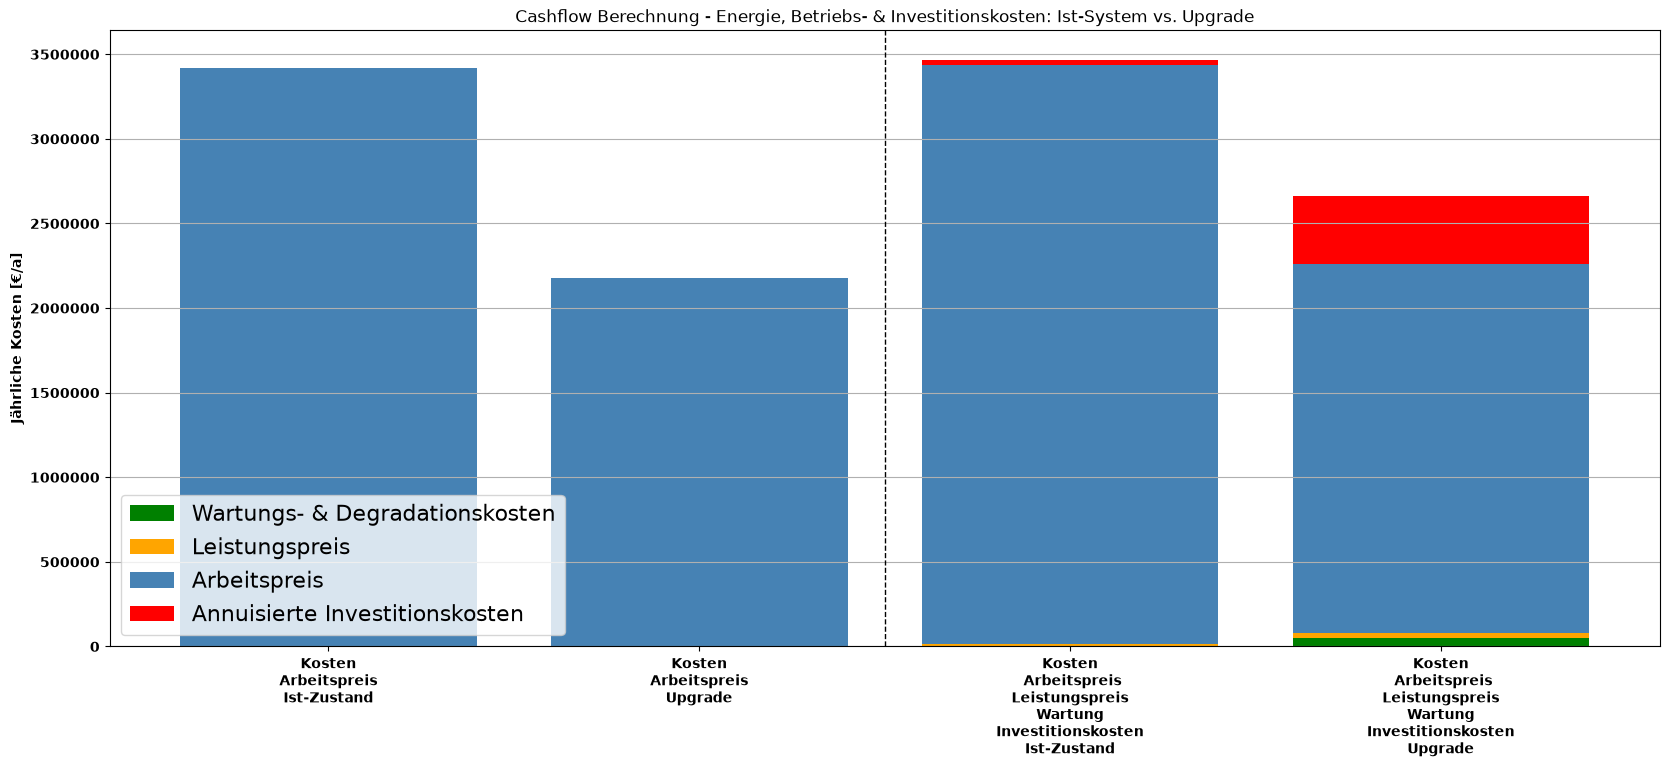

In [244]:
labels_ax2 = [
    "Kosten\nArbeitspreis\nIst-Zustand",
    "Kosten\nArbeitspreis\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nUpgrade",
]

x2 = np.arange(len(labels_ax2))

plt.figure(figsize=(20, 8))

# Arbeitspreis
plt.bar(x2[0], ap_is, color="steelblue")
plt.bar(x2[1], ap_up, color="steelblue")

# Opex & Capex Ist-Zustand
plt.bar(x2[2], ds_is, color="green")
plt.bar(x2[2], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[2], ap_is, bottom=ds_is + lp_is, color="steelblue")
plt.bar(
    x2[2],
    diesel_a,
    bottom=ds_is + lp_is + ap_is,
    color="red"
)

# Opex & Capex Upgrade
plt.bar(x2[3], es_up, color="green", label="Wartungs- & Degradationskosten")
plt.bar(x2[3], lp_up, bottom=es_up, color="orange", label="Leistungspreis")
plt.bar(x2[3], ap_up, bottom=es_up + lp_up, color="steelblue", label="Arbeitspreis")
plt.bar(
    x2[3],
    pv_a,
    bottom=es_up + lp_up + ap_up,
    color="red"
)
plt.bar(
    x2[3],
    annuity_bess,
    bottom=es_up + lp_up + ap_up + pv_a,
    color="red", label='Annuisierte Investitionskosten'
)

plt.xticks(x2, labels_ax2)

plt.ylabel(
    "Jährliche Kosten [€/a]",
    fontweight="bold"
)

plt.ticklabel_format(style="plain", axis="y")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.title(
    "Cashflow Berechnung - Energie, Betriebs- & Investitionskosten: Ist-System vs. Upgrade"
)

plt.axvline(1.5, color='black', linestyle='--', linewidth=1, alpha=1)

plt.grid(axis="y")

plt.legend(loc='lower left', fontsize=16)

plt.show()

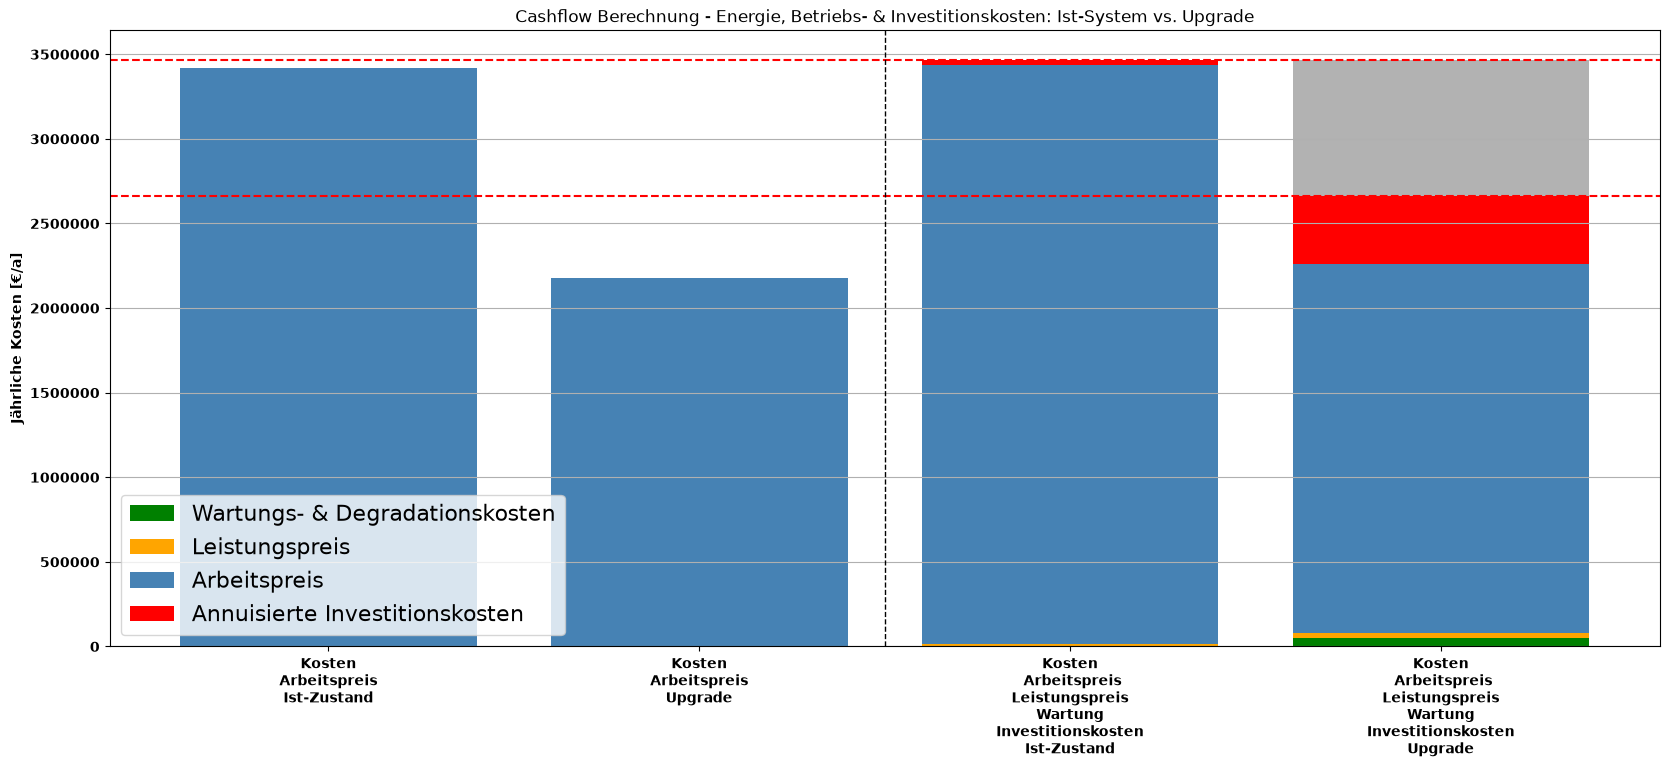

In [245]:
cashflow_is = (ds_is + lp_is + ap_is + diesel_a)

cashflow_up = (es_up + lp_up + ap_up + pv_a + annuity_bess)

cashflow_diff = cashflow_is - cashflow_up

labels_ax2 = [
    "Kosten\nArbeitspreis\nIst-Zustand",
    "Kosten\nArbeitspreis\nUpgrade",

    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nIst-Zustand",
    "Kosten\n Arbeitspreis\nLeistungspreis\nWartung\nInvestitionskosten\nUpgrade",
]

x2 = np.arange(len(labels_ax2))

plt.figure(figsize=(20, 8))

# Arbeitspreis
plt.bar(x2[0], ap_is, color="steelblue")
plt.bar(x2[1], ap_up, color="steelblue")

# Opex & Capex Ist-Zustand
plt.bar(x2[2], ds_is, color="green")
plt.bar(x2[2], lp_is, bottom=ds_is, color="orange")
plt.bar(x2[2], ap_is, bottom=ds_is + lp_is, color="steelblue")
plt.bar(x2[2], diesel_a, bottom=ds_is + lp_is + ap_is, color="red")

# Opex & Capex Upgrade
plt.bar(x2[3], es_up, color="green", label="Wartungs- & Degradationskosten")
plt.bar(x2[3], lp_up, bottom=es_up, color="orange", label="Leistungspreis")
plt.bar(x2[3], ap_up, bottom=es_up + lp_up, color="steelblue", label="Arbeitspreis")
plt.bar(x2[3], pv_a, bottom=es_up + lp_up + ap_up, color="red")
plt.bar(x2[3], annuity_bess, bottom=es_up + lp_up + ap_up + pv_a, color="red", label='Annuisierte Investitionskosten')
plt.bar(
    x2[3],
    (ds_is + lp_is + ap_is + diesel_a) - (es_up + lp_up + ap_up + pv_a + annuity_bess),
    bottom=es_up + lp_up + ap_up + pv_a + annuity_bess,
    color="grey",
    alpha=0.6
)

plt.xticks(x2, labels_ax2)

plt.axhline(ds_is + lp_is + ap_is + diesel_a, color='red', linewidth=1.5, linestyle='--')

plt.axhline(es_up + lp_up + ap_up + pv_a + annuity_bess, color='red', linewidth=1.5, linestyle='--')

plt.ylabel(
    "Jährliche Kosten [€/a]",
    fontweight="bold"
)

plt.ticklabel_format(style="plain", axis="y")

for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.title(
    "Cashflow Berechnung - Energie, Betriebs- & Investitionskosten: Ist-System vs. Upgrade"
)

plt.grid(axis="y")

plt.axvline(1.5, color='black', linestyle='--', linewidth=1, alpha=1)

plt.legend(loc='lower left', fontsize=16)

plt.show()

### Fazit

Sensitivität

In [ ]:
# 1. Wrapper-Funktion für dynamische Kosten
def make_sensitivity_function(cost_multiplier):
    def custom_optimization(n, snapshots):
        m = n.model
        
        # --- Dein bestehender Code für diskrete Größen startet hier ---
        p_nom_var = m.variables['StorageUnit-p_nom']
        dim_name = p_nom_var.dims[0]
        p_nom_bess = p_nom_var.sel({dim_name: 'Batteriespeicher'})
        
        sizes_kwh = np.arange(500, 12500, 500)
        sizes_index = pd.Index(sizes_kwh, name='storage_size')
        
        xp = [1000, 3500, 7000, 10000]
        
        # WICHTIG: Hier greift der Multiplikator für die Sensitivität!
        fp = [360 * cost_multiplier, 310 * cost_multiplier, 285 * cost_multiplier, 273 * cost_multiplier]
        spec_costs = np.interp(sizes_kwh, xp, fp)
        
        # ... (Füge hier exakt den restlichen Code deiner "add_discrete_bess_sizes" Funktion 
        # inklusive Binärvariablen, SOC-Constraints und m.objective += ... ein) ...
        
        # Falls du FCR nutzt, hier ebenfalls aufrufen:
        # add_fcr_optimization(n, snapshots)

    return custom_optimization

# 2. Kostenszenarien definieren (z.B. -50% bis +50%)
multipliers = [0.5, 0.75, 1.0, 1.25, 1.5]
sensitivity_results = []

# 3. Optimierungsschleife
for multiplier in multipliers:
    print(f"\nOptimierung mit Speicherkosten-Faktor: {multiplier}x gestartet...")
    
    # Netzwerk mit dem neuen Kostenfaktor lösen
    status, condition = n_up.optimize(
        solver_name="highs",
        extra_functionality=make_sensitivity_function(multiplier)
    )
    
    # Ergebnisse auslesen
    chosen_p_nom = n_up.storage_units.at["Batteriespeicher", "p_nom_opt"]
    chosen_capacity_kwh = chosen_p_nom * max_hours 
    total_costs = n_up.objective
    
    sensitivity_results.append({
        "Kostenfaktor": f"{multiplier * 100}%",
        "Spezifische Kosten (Basis 10MWh) [€/kWh]": 273 * multiplier,
        "Gewählte Kapazität [kWh]": chosen_capacity_kwh,
        "Gewählte Leistung [kW]": chosen_p_nom,
        "Gesamtsystemkosten [€]": total_costs
    })

# 4. Auswertung und Visualisierung
sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)

plt.figure(figsize=(10, 5))
plt.plot(multipliers, sensitivity_df["Gewählte Kapazität [kWh]"], marker="o", color="blue", linewidth=2)
plt.title("Sensitivität: Batteriespeichergröße bei veränderten CAPEX")
plt.xlabel("Kostenfaktor (1.0 = Basispreise)")
plt.ylabel("Optimale Speicherkapazität [kWh]")
plt.grid(True)
plt.show()

C:\Users\Juli\AppData\Local\Temp\ipykernel_1500\489932178.py:37: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n_up.optimize(
Index(['electricity'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')



Optimierung mit Speicherkosten-Faktor: 0.5x gestartet...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 213.06it/s]
INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210241 primals, 490561 duals
Objective: 2.35e+05
Solver: highs
Runtime: 214.50s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
C:\Users\Juli\AppData\Local\Temp\ipykernel_1500\489932178.py:37: FutureWarning: The default value of `include_objective_constant` will change from True


Optimierung mit Speicherkosten-Faktor: 0.75x gestartet...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 182.90it/s]
INFO:linopy.io: Writing time: 0.25s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210241 primals, 490561 duals
Objective: 2.35e+05
Solver: highs
Runtime: 227.93s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
C:\Users\Juli\AppData\Local\Temp\ipykernel_1500\489932178.py:37: FutureWarning: The default value of `include_objective_constant` will change from True

...


Optimierung mit Speicherkosten-Faktor: 1.25x gestartet...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 164.52it/s]
INFO:linopy.io: Writing time: 0.28s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210241 primals, 490561 duals
Objective: 2.35e+05
Solver: highs
Runtime: 235.43s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
C:\Users\Juli\AppData\Local\Temp\ipykernel_1500\489932178.py:37: FutureWarning: The default value of `include_objective_constant` will change from True


Optimierung mit Speicherkosten-Faktor: 1.5x gestartet...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 183.18it/s]
INFO:linopy.io: Writing time: 0.26s


KeyboardInterrupt: 